# LAB 02 - THỰC HÀNH: CÁC GIẢI THUẬT PHÂN LOẠI CƠ BẢN

## 2.1. GIẢI THUẬT 1: CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY

### Bài toán 1

#### Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn

In [1]:
# Tải một số package và package graphviz, để vẽ cây quyết định
# !pip install graphviz
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

In [3]:
# Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan đến bài toán cần giải quyết
df = pd.read_csv("Data/default_of_credit_card_clients.csv") #Load the cleaned data
features_response = df.columns.tolist() #Get a list of column names
#Make a list of columns to remove that aren't features or the response variable
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3',\
 'PAY_4', 'PAY_5', 'PAY_6',\
 'EDUCATION_CAT', 'graduate school',\
 'high school', 'none',\
 'others', 'university']
features_response = [item for item in features_response if item not
in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [4]:
# Chuẩn bị dữ liệu cho tập train và tập test
from sklearn.model_selection import train_test_split
from sklearn import tree
#Split the data into training and testing sets using the same random seed
X_train, X_test, y_train, y_test = \
     train_test_split(df[features_response[:-1]].values,
     df['default payment next month'].values,
     test_size=0.2, random_state=24)

In [5]:
# Xây dựng cây quyết định từ lớp DecisionTreeClassifier có trong thư viện Scikit-Learn
# the tree will grow to a depth of at most 2
dt = tree.DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

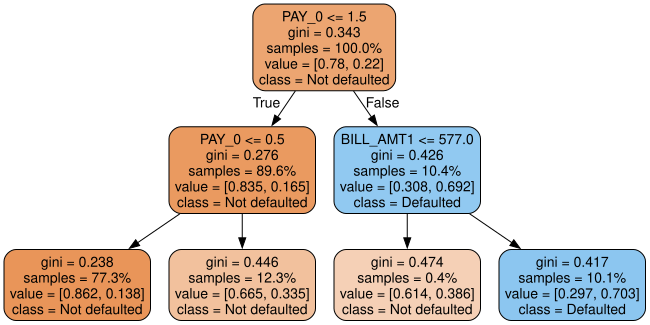

In [6]:
# Hiển thị cây quyết định với package graphviz
# *Cài đặt phần mềm Graphviz về máy trước khi chạy*
dot_data = tree.export_graphviz(dt,
     out_file=None,
     filled=True,
     rounded=True,
     feature_names=\
         features_response[:-1],
         proportion=True,
         class_names=['Not defaulted', 'Defaulted'])
graph = graphviz.Source(dot_data)
graph

#### Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau 

In [7]:
# Tạo cây quyết định và xác định các giá trị tham số có thể chọn để tìm tham số tối ưu
from sklearn.model_selection import GridSearchCV
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]} #parameters
dt = tree.DecisionTreeClassifier() #tree modal
cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc',
 n_jobs=None, refit=True, cv=4, verbose=1,
 error_score=np.nan,
 return_train_score=True) # cv is the best model
cv.fit(X_train, y_train)

Fitting 4 folds for each of 7 candidates, totalling 28 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 4, 6, 8, 10, 12]},
             return_train_score=True, scoring='roc_auc', verbose=1)

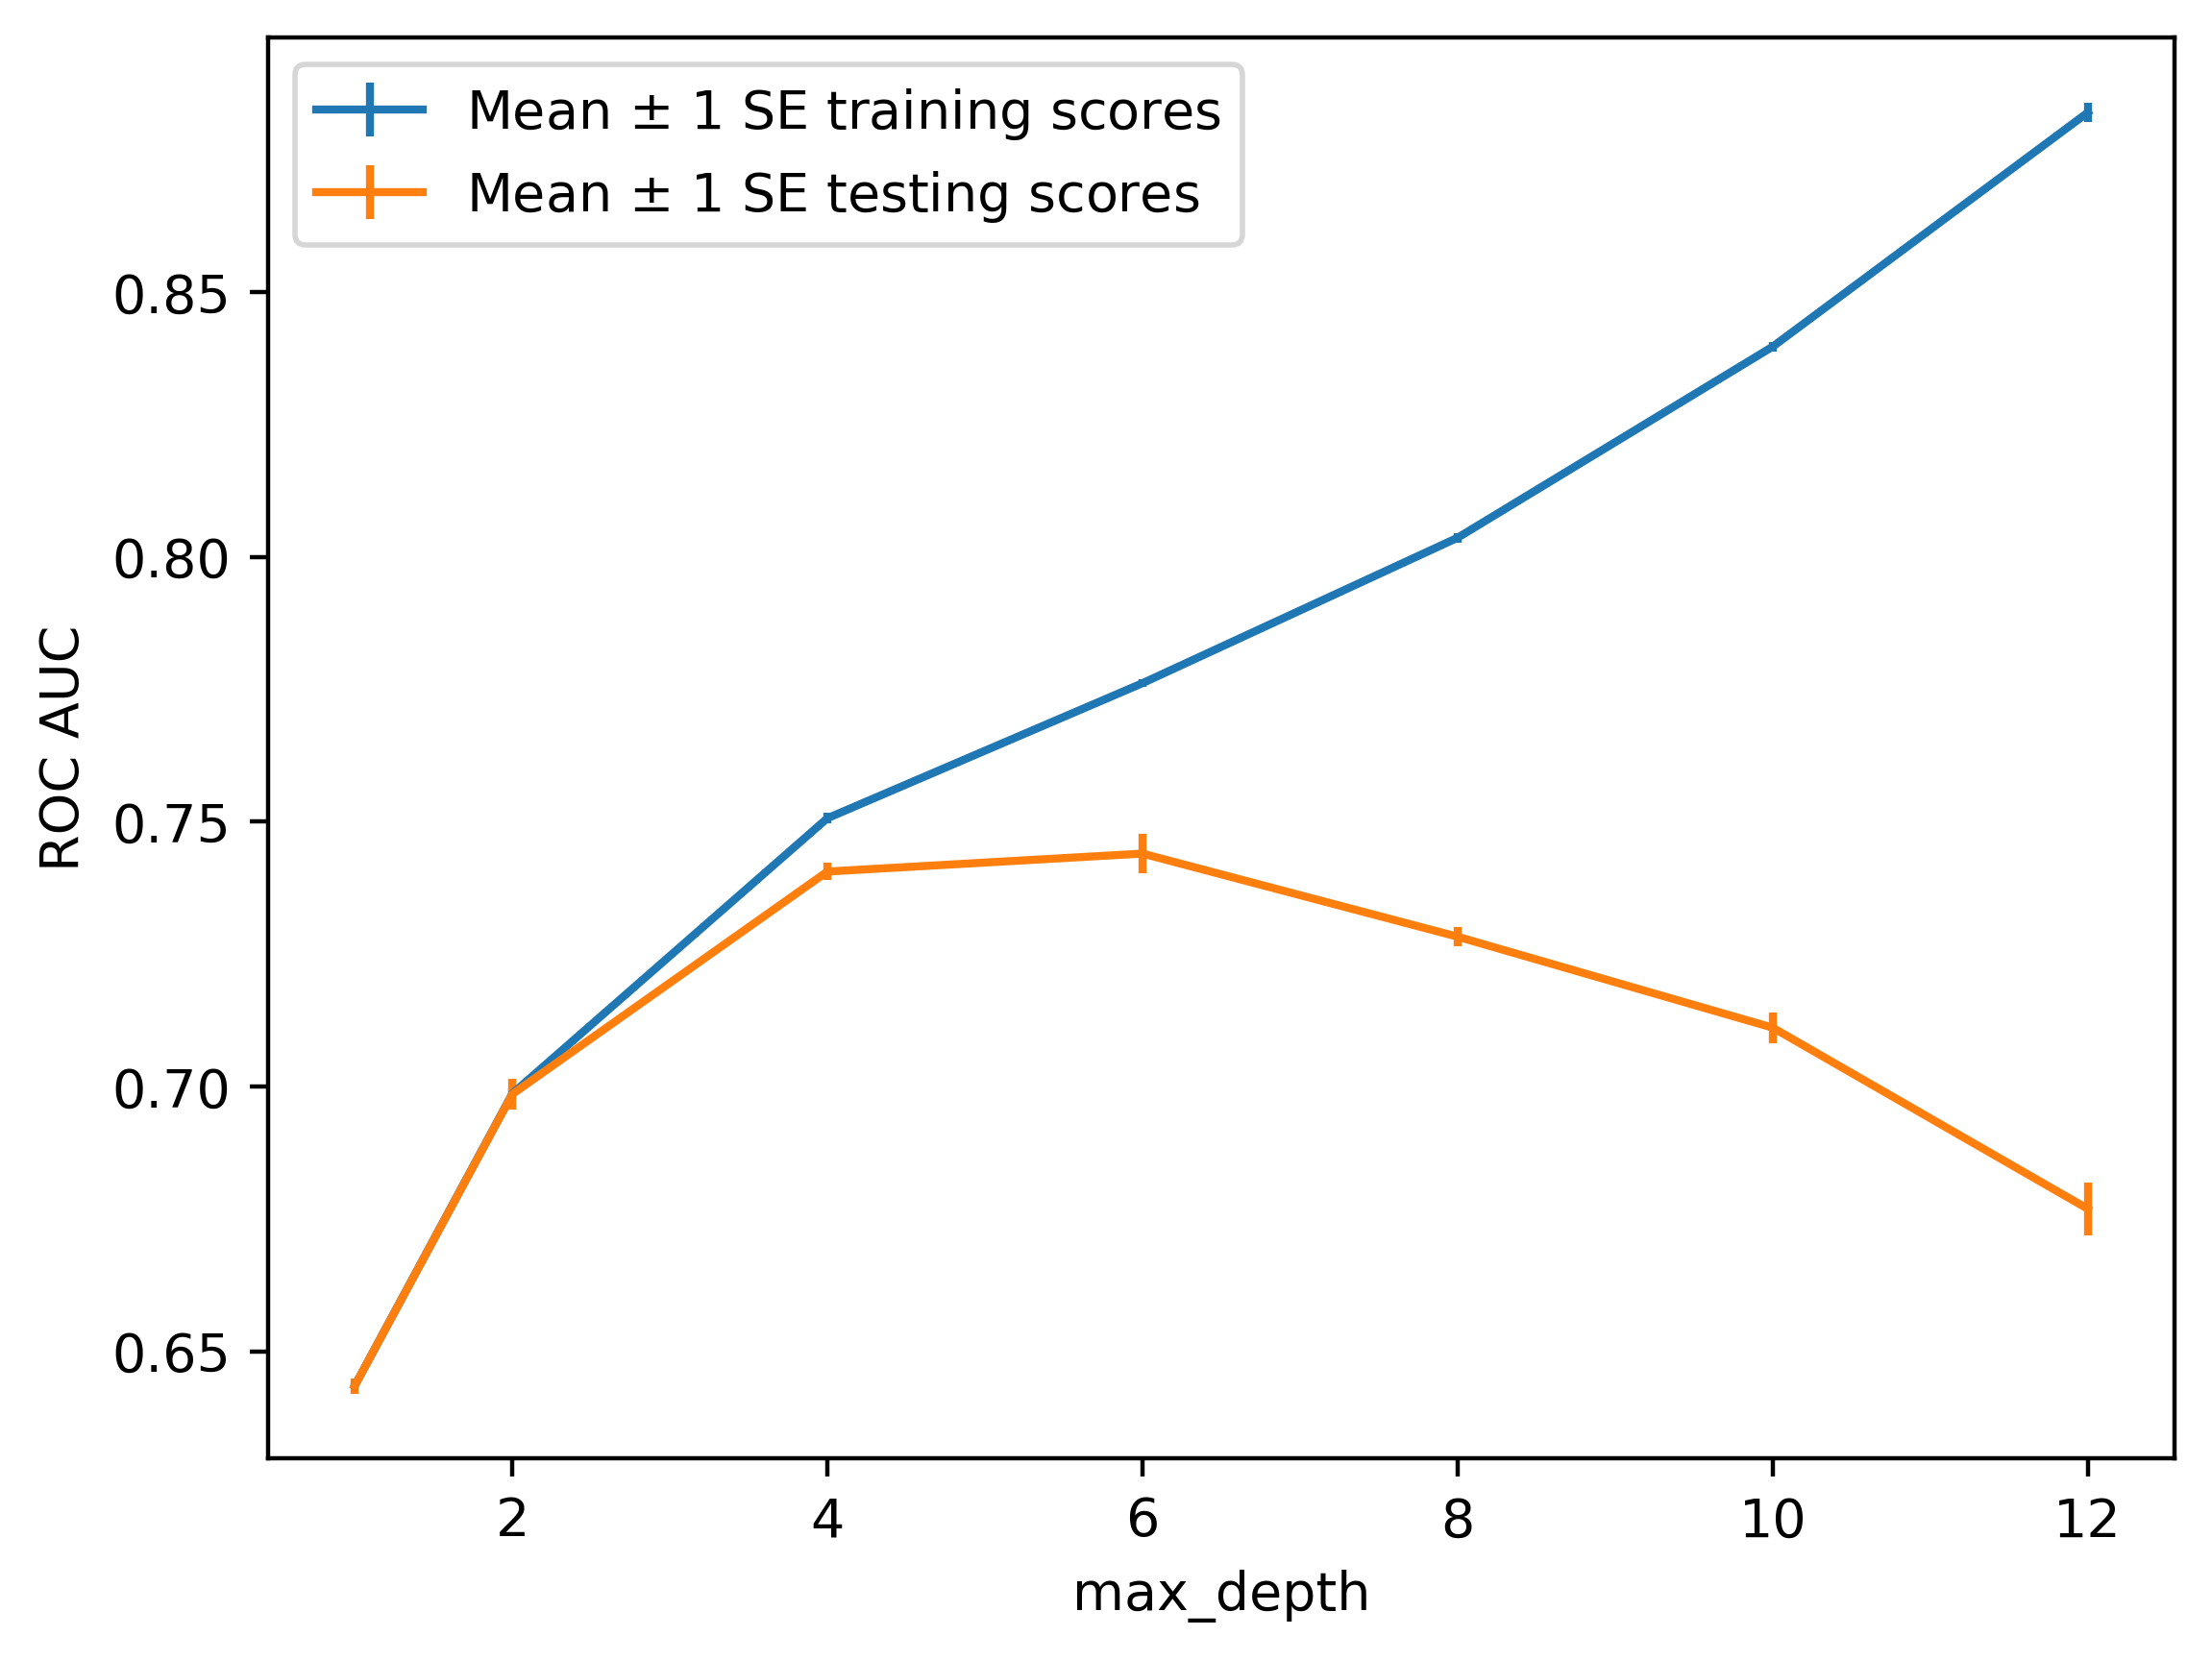

In [8]:
# Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau
cv_results_df = pd.DataFrame(cv.cv_results_)
#View the names of the remaining columns in the results DataFrame
cv_results_df.columns
# Vẽ error bar
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
 cv_results_df['mean_train_score'],
 yerr=cv_results_df['std_train_score']/np.sqrt(4),
 label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
 cv_results_df['mean_test_score'],
 yerr=cv_results_df['std_test_score']/np.sqrt(4),
 label='Mean $\pm$ 1 SE testing scores')
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')

plt.show()

In [10]:
# Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier\
 (n_estimators=10, criterion='gini', max_depth=3,
 min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
 max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
 bootstrap=True, oob_score=False, n_jobs=None,
 random_state=4, verbose=0, warm_start=False, class_weight=None)

In [11]:
# Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó
#a parameter grid for this exercise in order to search the numbers of trees, ranging from 10 to 100 by 10s
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex,
    scoring='roc_auc', n_jobs=None,
    refit=True, cv=4, verbose=1,
    error_score=float('nan'),
    return_train_score=True)
cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(max_depth=3, n_estimators=10,
                                              random_state=4),
             param_grid={'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             return_train_score=True, scoring='roc_auc', verbose=1)

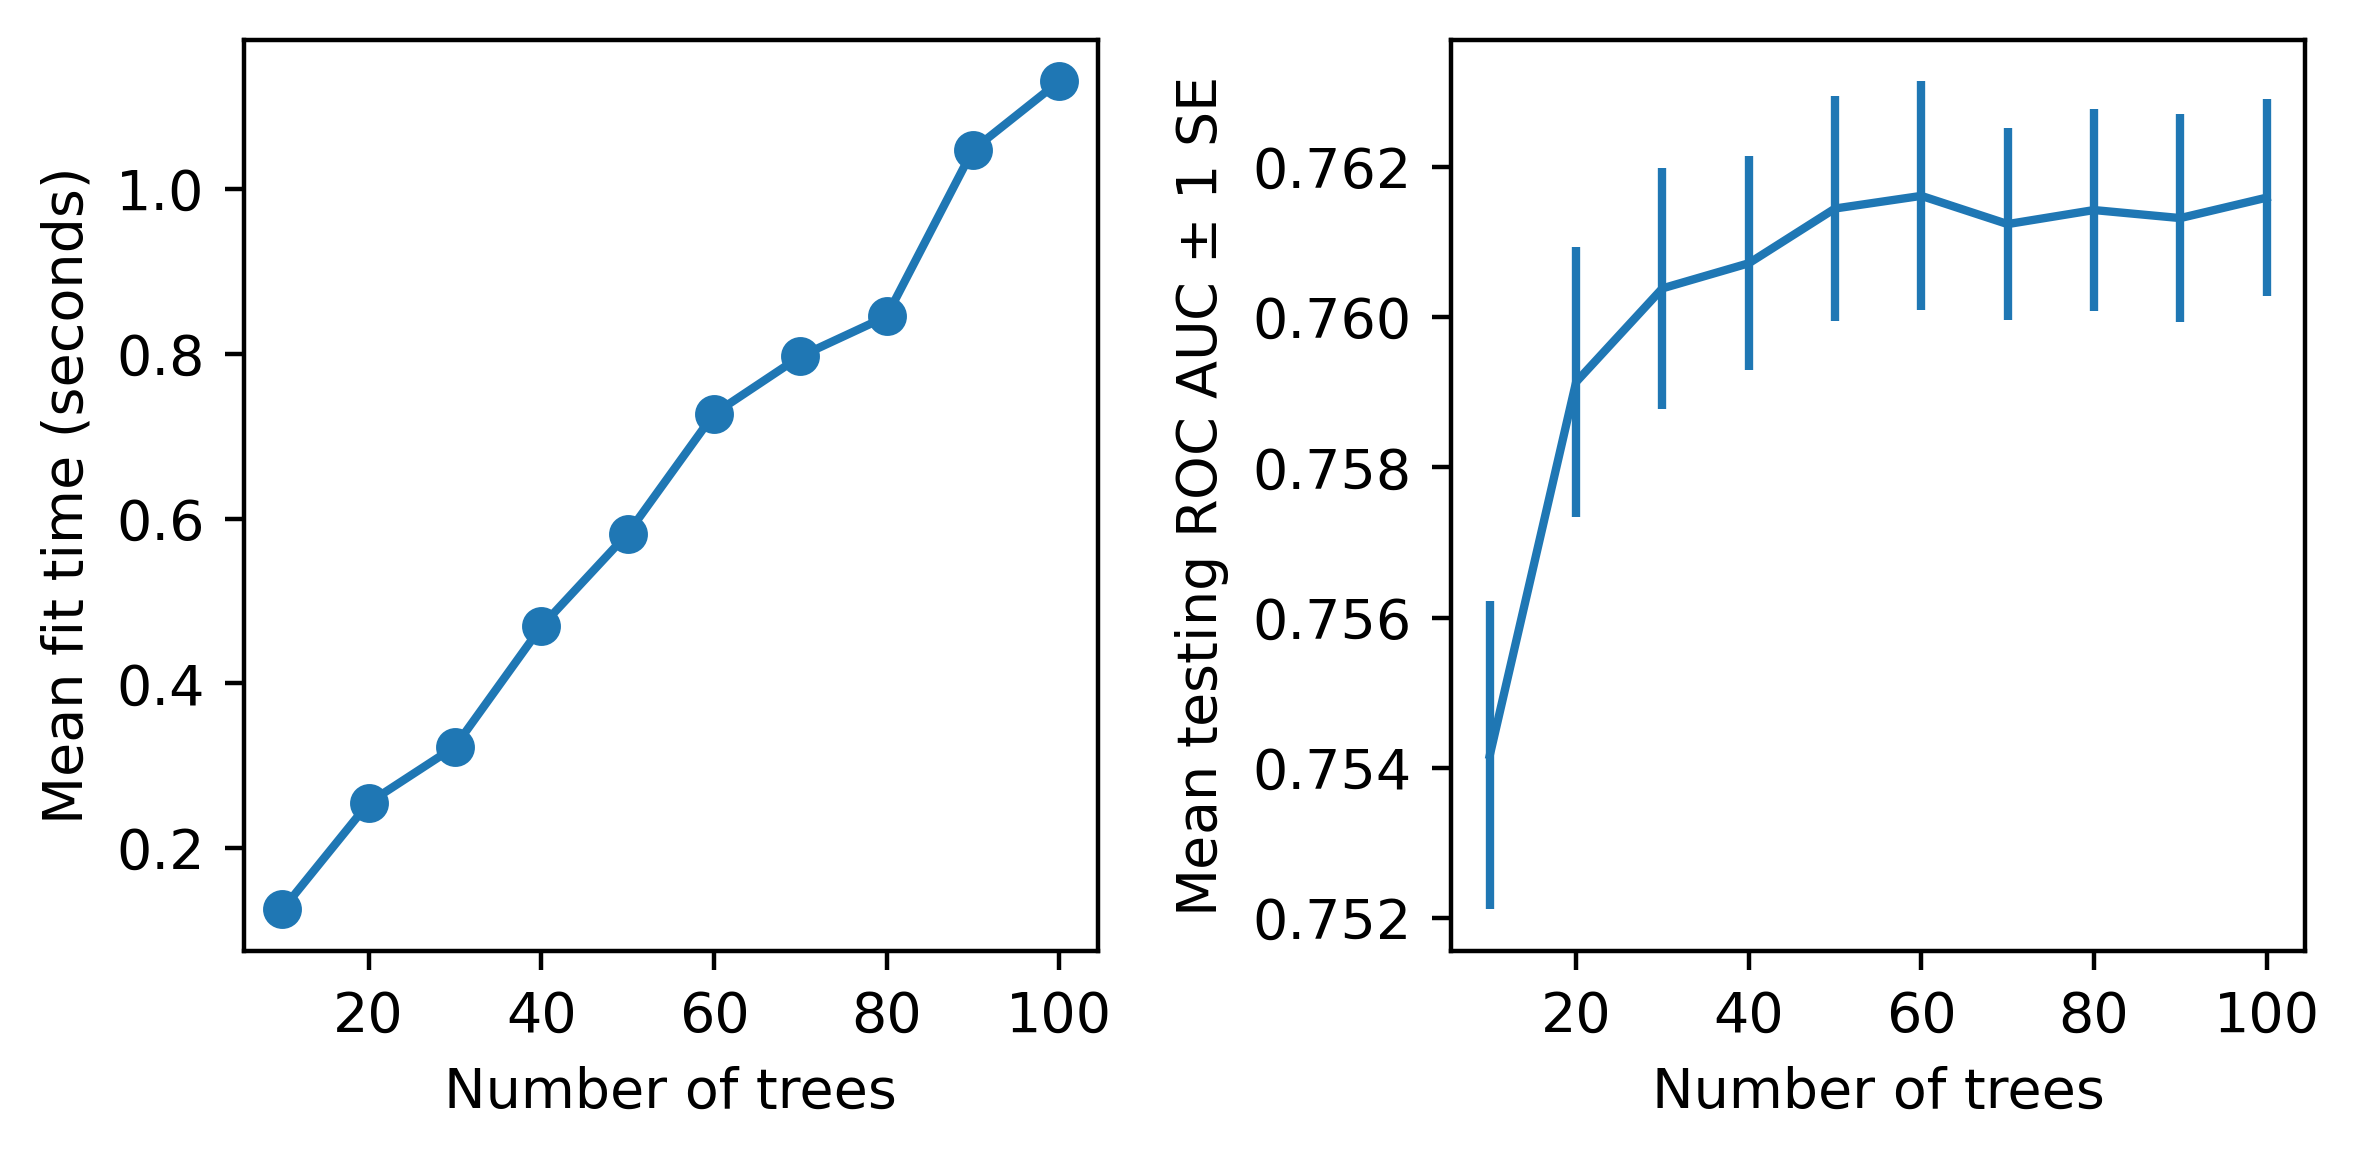

In [12]:
# Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau
plt.close()
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
 cv_rf_ex_results_df['mean_fit_time'],
 '-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
 cv_rf_ex_results_df['mean_test_score'],
 yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')

plt.tight_layout()
plt.show()

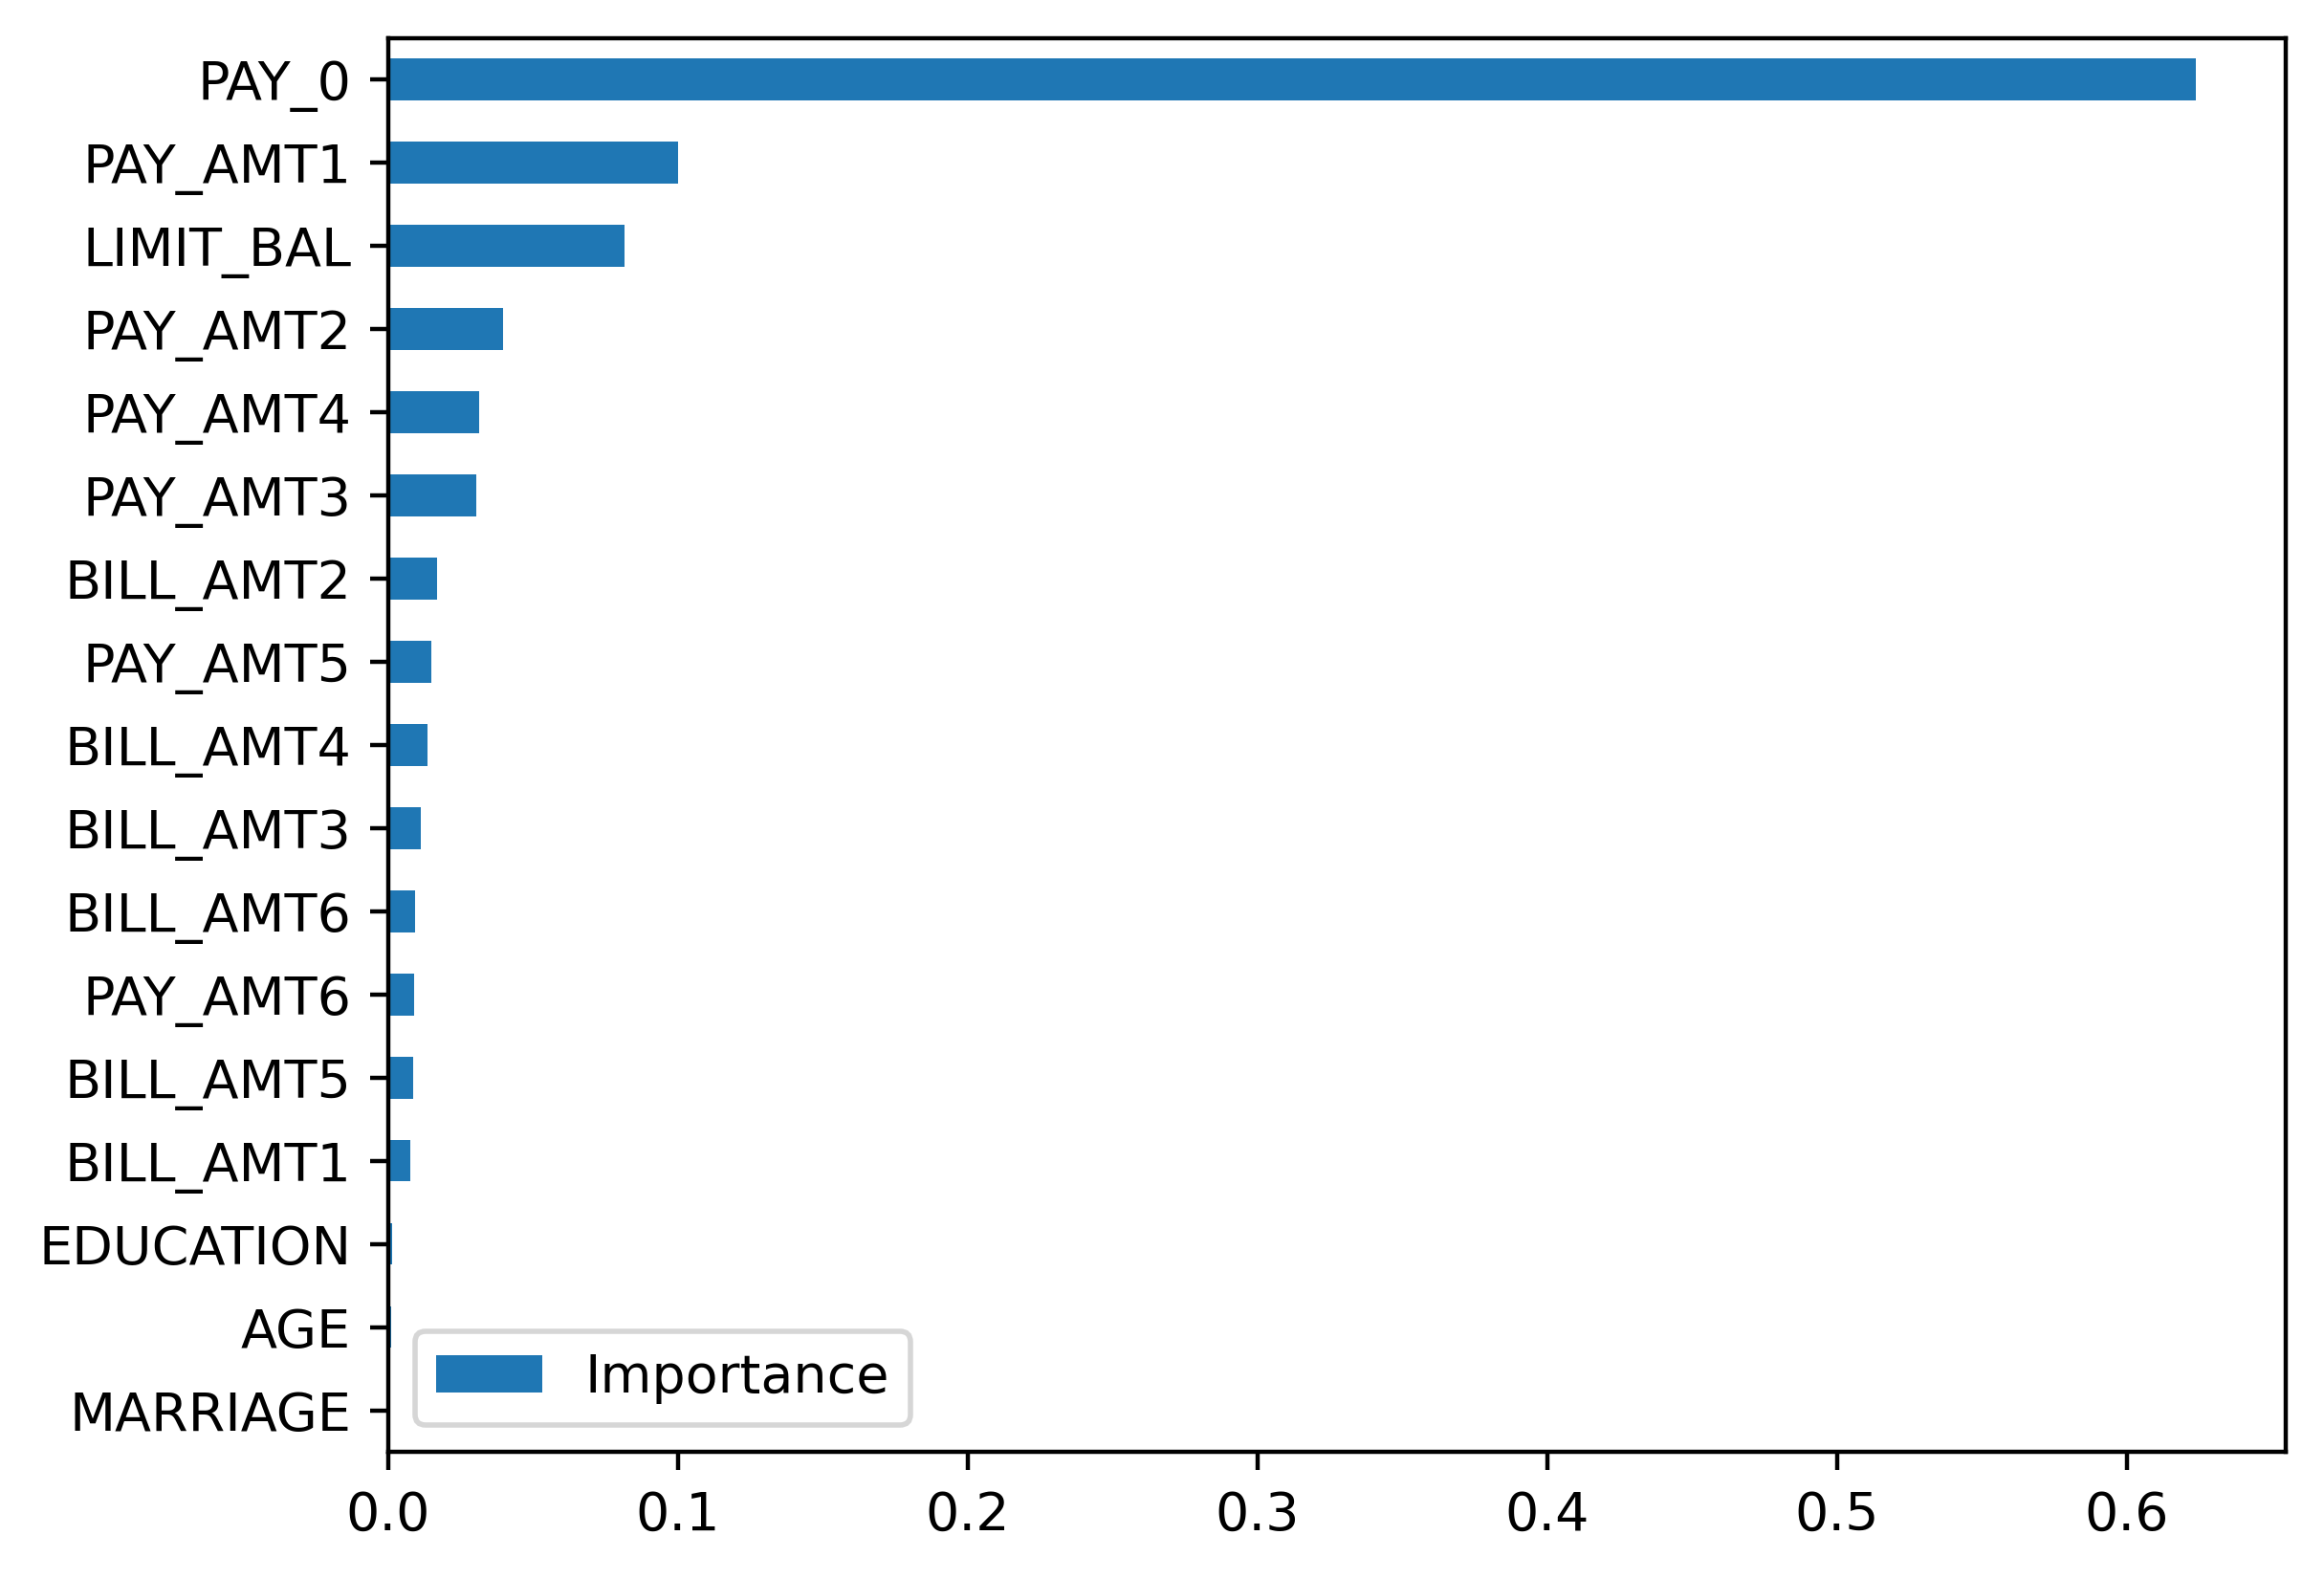

In [13]:
# Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham số tốt nhất
plt.close()
# {'n_estimators': 50}
cv_rf_ex.best_params_
# the feature names and importances
feat_imp_df = pd.DataFrame({
 'Importance':cv_rf_ex.best_estimator_.feature_importances_},
 index=features_response[:-1])
feat_imp_df.sort_values('Importance', ascending=True).plot.barh()

plt.show()

### Bài tập thực hành 1

In [14]:
# Load dữ liệu huấn luyện và kiểm tra
import pandas as pd
train_df = pd.read_csv("Data/train.csv")
test_df = pd.read_csv("Data/test.csv")

In [15]:
# Kiểm tra dữ liệu
train_df.head()
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
# Tiền xử lý dữ liệu

# Chọn các cột quan trọng
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

# Điền giá trị thiếu (gán trực tiếp, không dùng inplace trên Series)
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Chuyển biến phân loại thành số
train_df = pd.get_dummies(train_df, columns=['Sex', 'Embarked'], drop_first=True)

# Tách X và y
X_train = train_df.drop(columns=['PassengerId','Survived','Name','Ticket','Cabin'])
y_train = train_df['Survived']

Accuracy: 0.8271604938271605


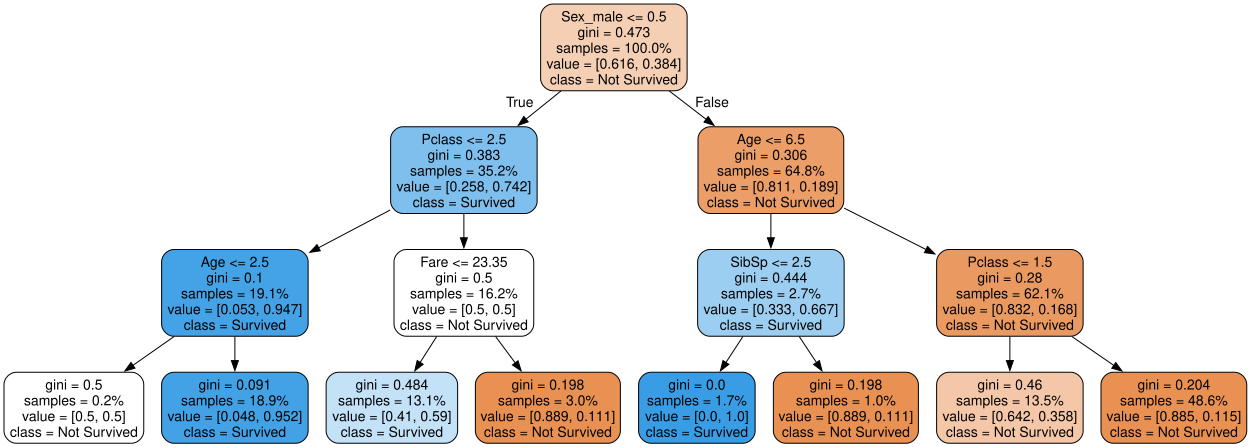

In [17]:
# Xây dựng cây quyết định

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

# Tạo mô hình
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Đánh giá
y_pred = dt.predict(X_train)
from sklearn.metrics import accuracy_score, confusion_matrix
print("Accuracy:", accuracy_score(y_train, y_pred))

# Vẽ cây quyết định
dot_data = export_graphviz(dt, out_file=None,
                           feature_names=X_train.columns,
                           class_names=['Not Survived','Survived'],
                           filled=True, rounded=True,
                           proportion=True)
graph = graphviz.Source(dot_data)
graph

In [18]:
# Xây dựng mô hình Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

# Random Forest
rf = RandomForestClassifier(random_state=42)

# Grid search thử nghiệm số lượng cây
param_grid = {'n_estimators': list(range(10, 110, 10))}
cv_rf = GridSearchCV(rf, param_grid=param_grid,
                     scoring='roc_auc', cv=4,
                     return_train_score=True)
cv_rf.fit(X_train, y_train)

# Kết quả tốt nhất
print("Best n_estimators:", cv_rf.best_params_)

Best n_estimators: {'n_estimators': 80}


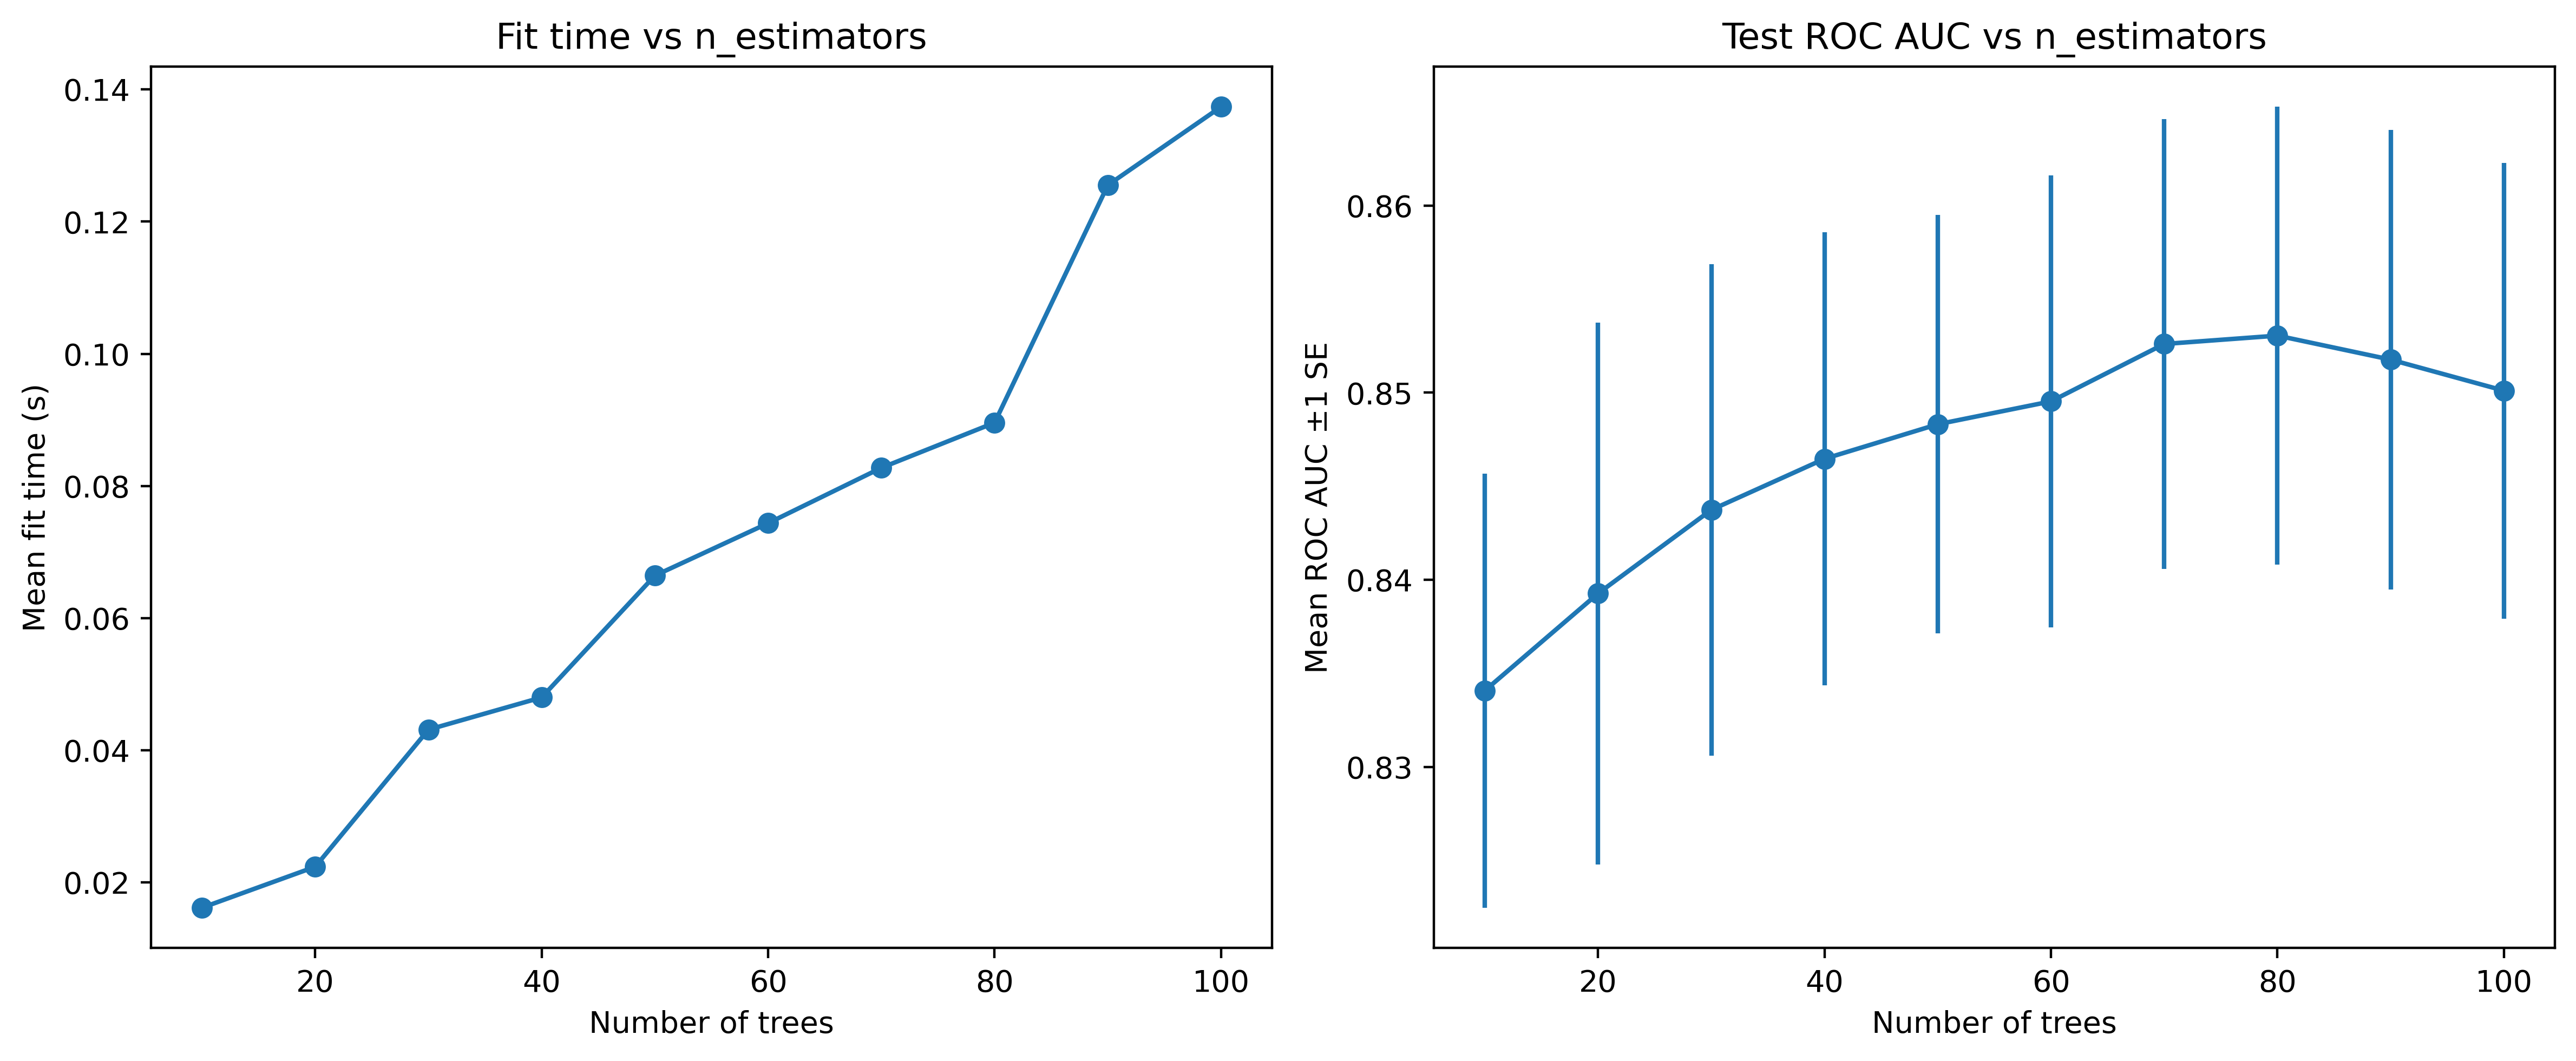

In [19]:
# Vẽ biểu đồ đánh giá mô hình Random Forest

cv_results_df = pd.DataFrame(cv_rf.cv_results_)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

# Thời gian fit
axs[0].plot(cv_results_df['param_n_estimators'],
            cv_results_df['mean_fit_time'], '-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (s)')
axs[0].set_title('Fit time vs n_estimators')

# ROC AUC test
axs[1].errorbar(cv_results_df['param_n_estimators'],
                cv_results_df['mean_test_score'],
                yerr=cv_results_df['std_test_score']/np.sqrt(4), fmt='-o')
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean ROC AUC ±1 SE')
axs[1].set_title('Test ROC AUC vs n_estimators')

plt.tight_layout()
plt.show()

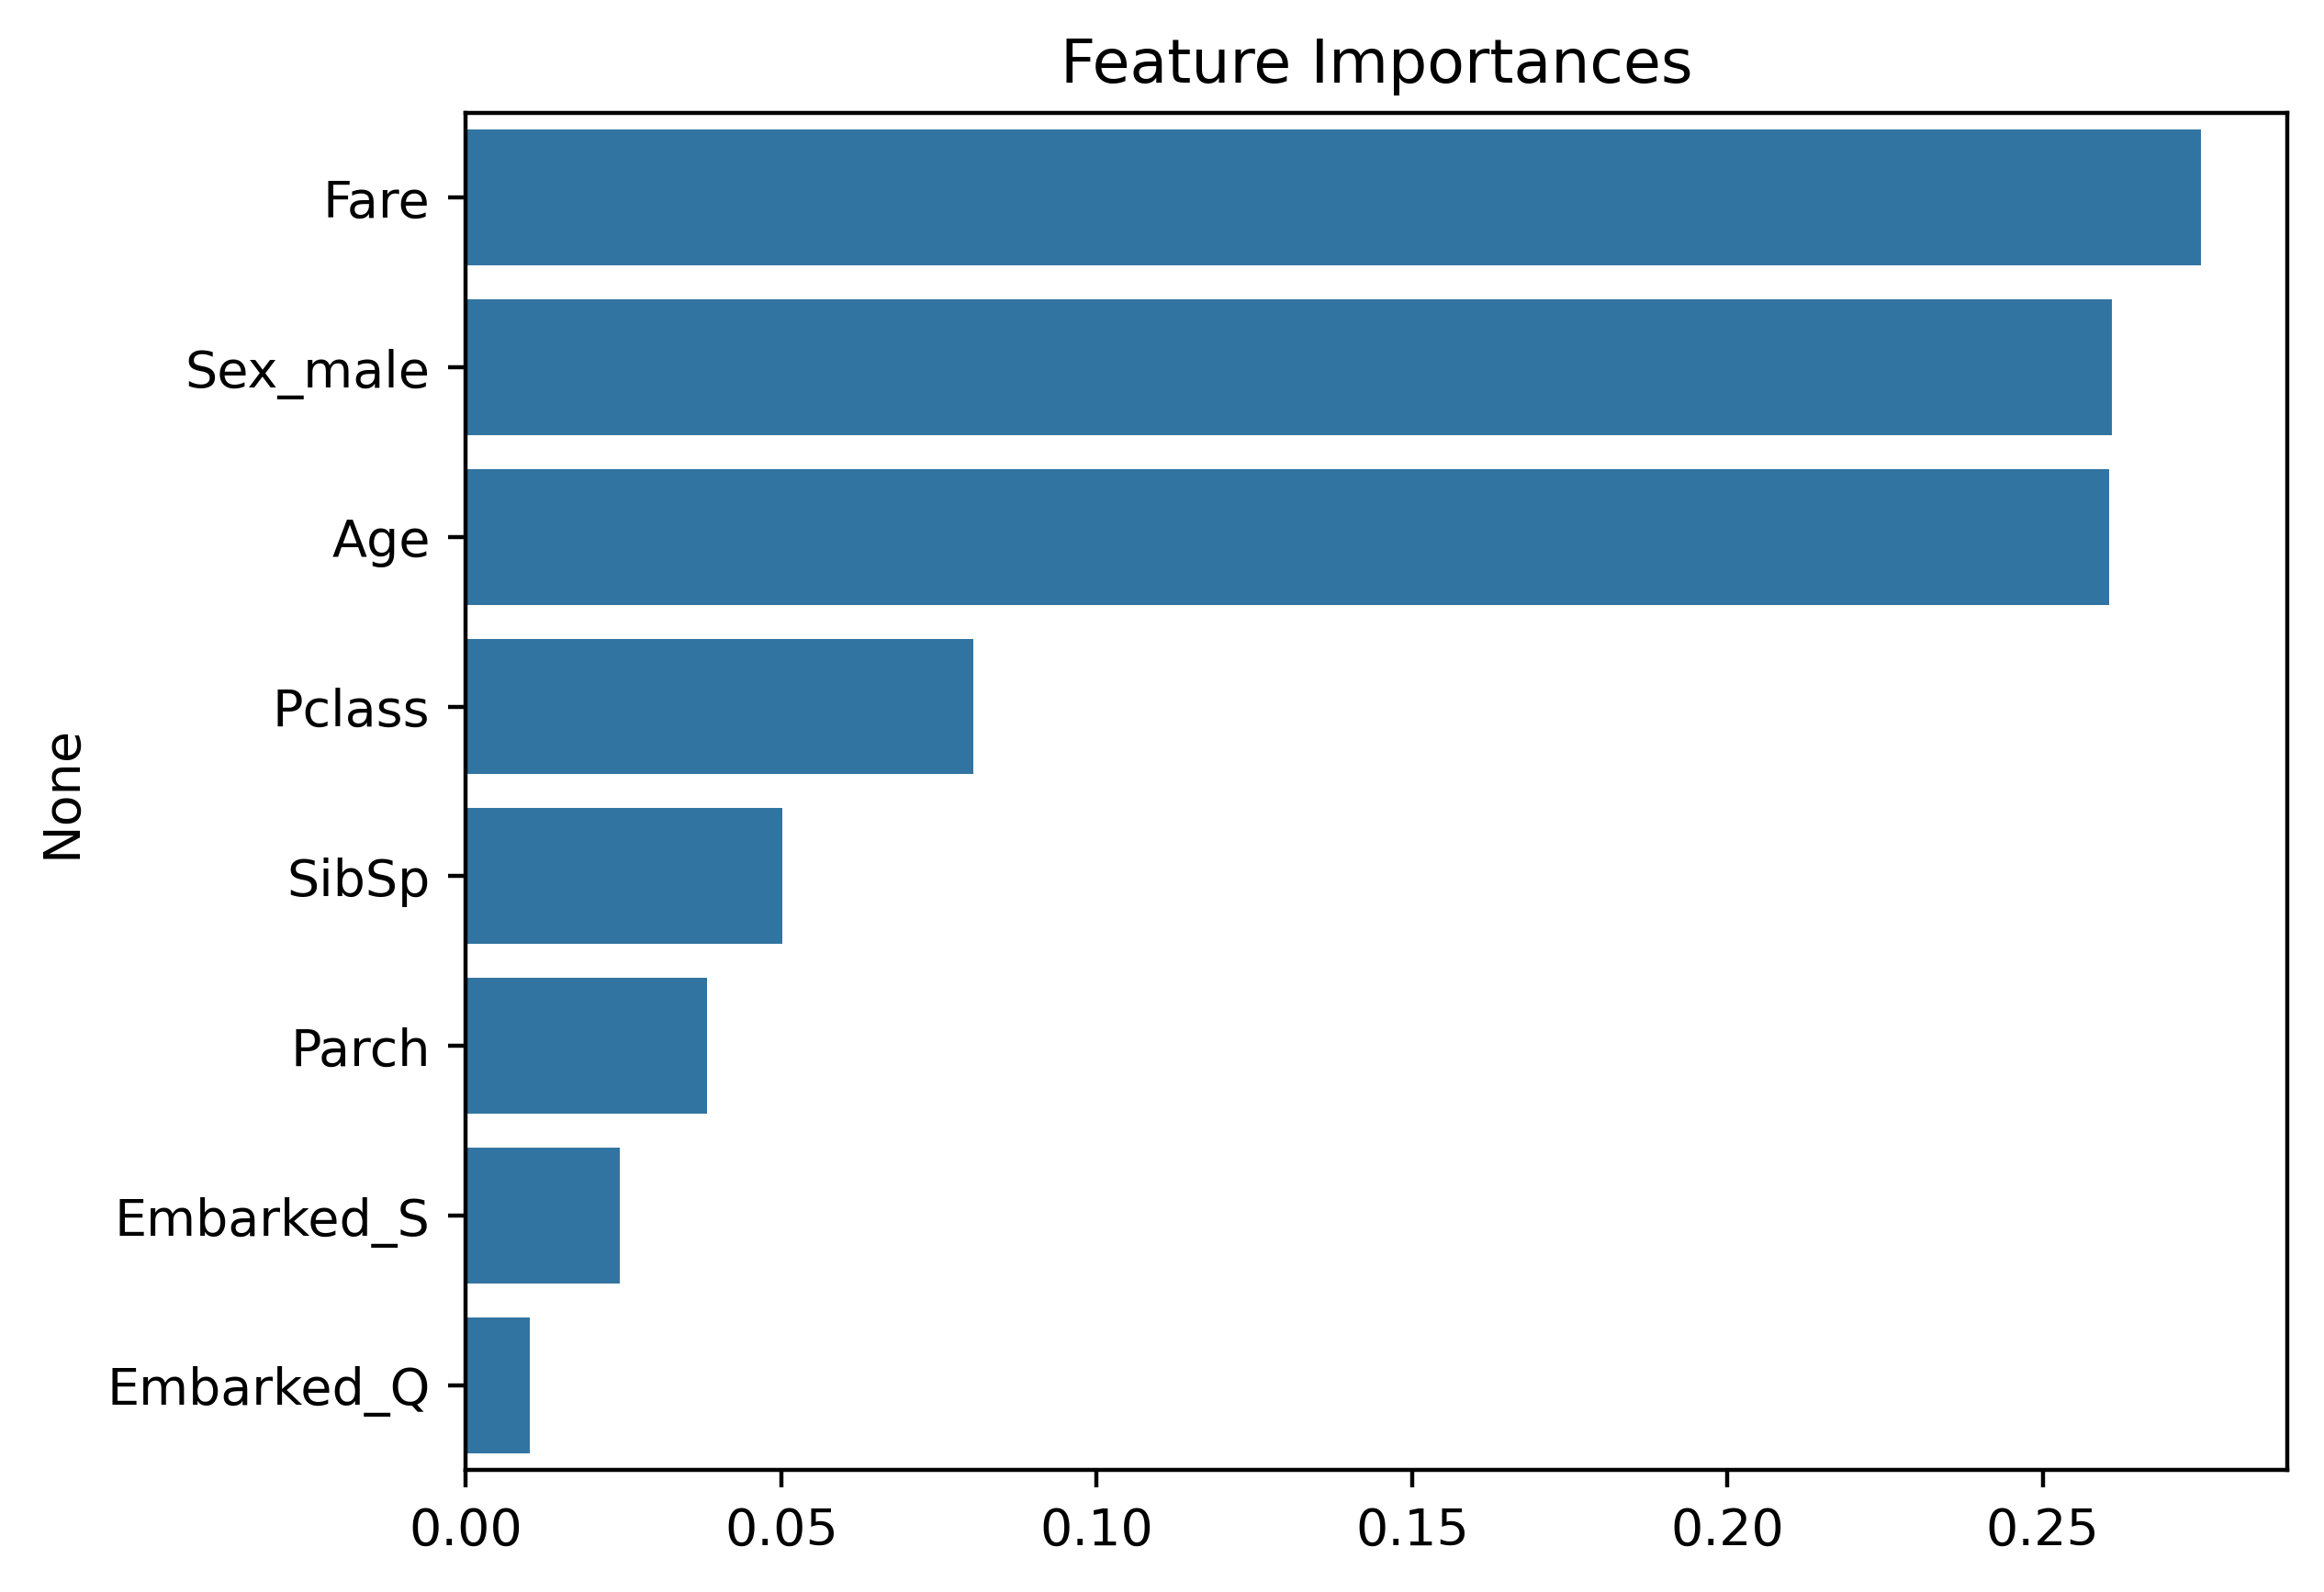

In [18]:
# Vẽ biểu đồ biến dự đoán quan trọng

best_rf = cv_rf.best_estimator_
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importances')
plt.show()

### Bài tập thực hành 2

In [20]:
# Load dữ liệu bệnh tiểu đường

import pandas as pd

df = pd.read_csv("Data/diabetes_prediction_dataset.csv")

In [21]:
# Tiền xử lý dữ liệu

# Chuyển đổi biến phân loại thành biến giả
df = pd.get_dummies(df, drop_first=True)

In [22]:
# Tách X và y
X = df.drop(columns=['diabetes'])
y = df['diabetes']

# Chia tập huấn luyện và kiểm tra
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

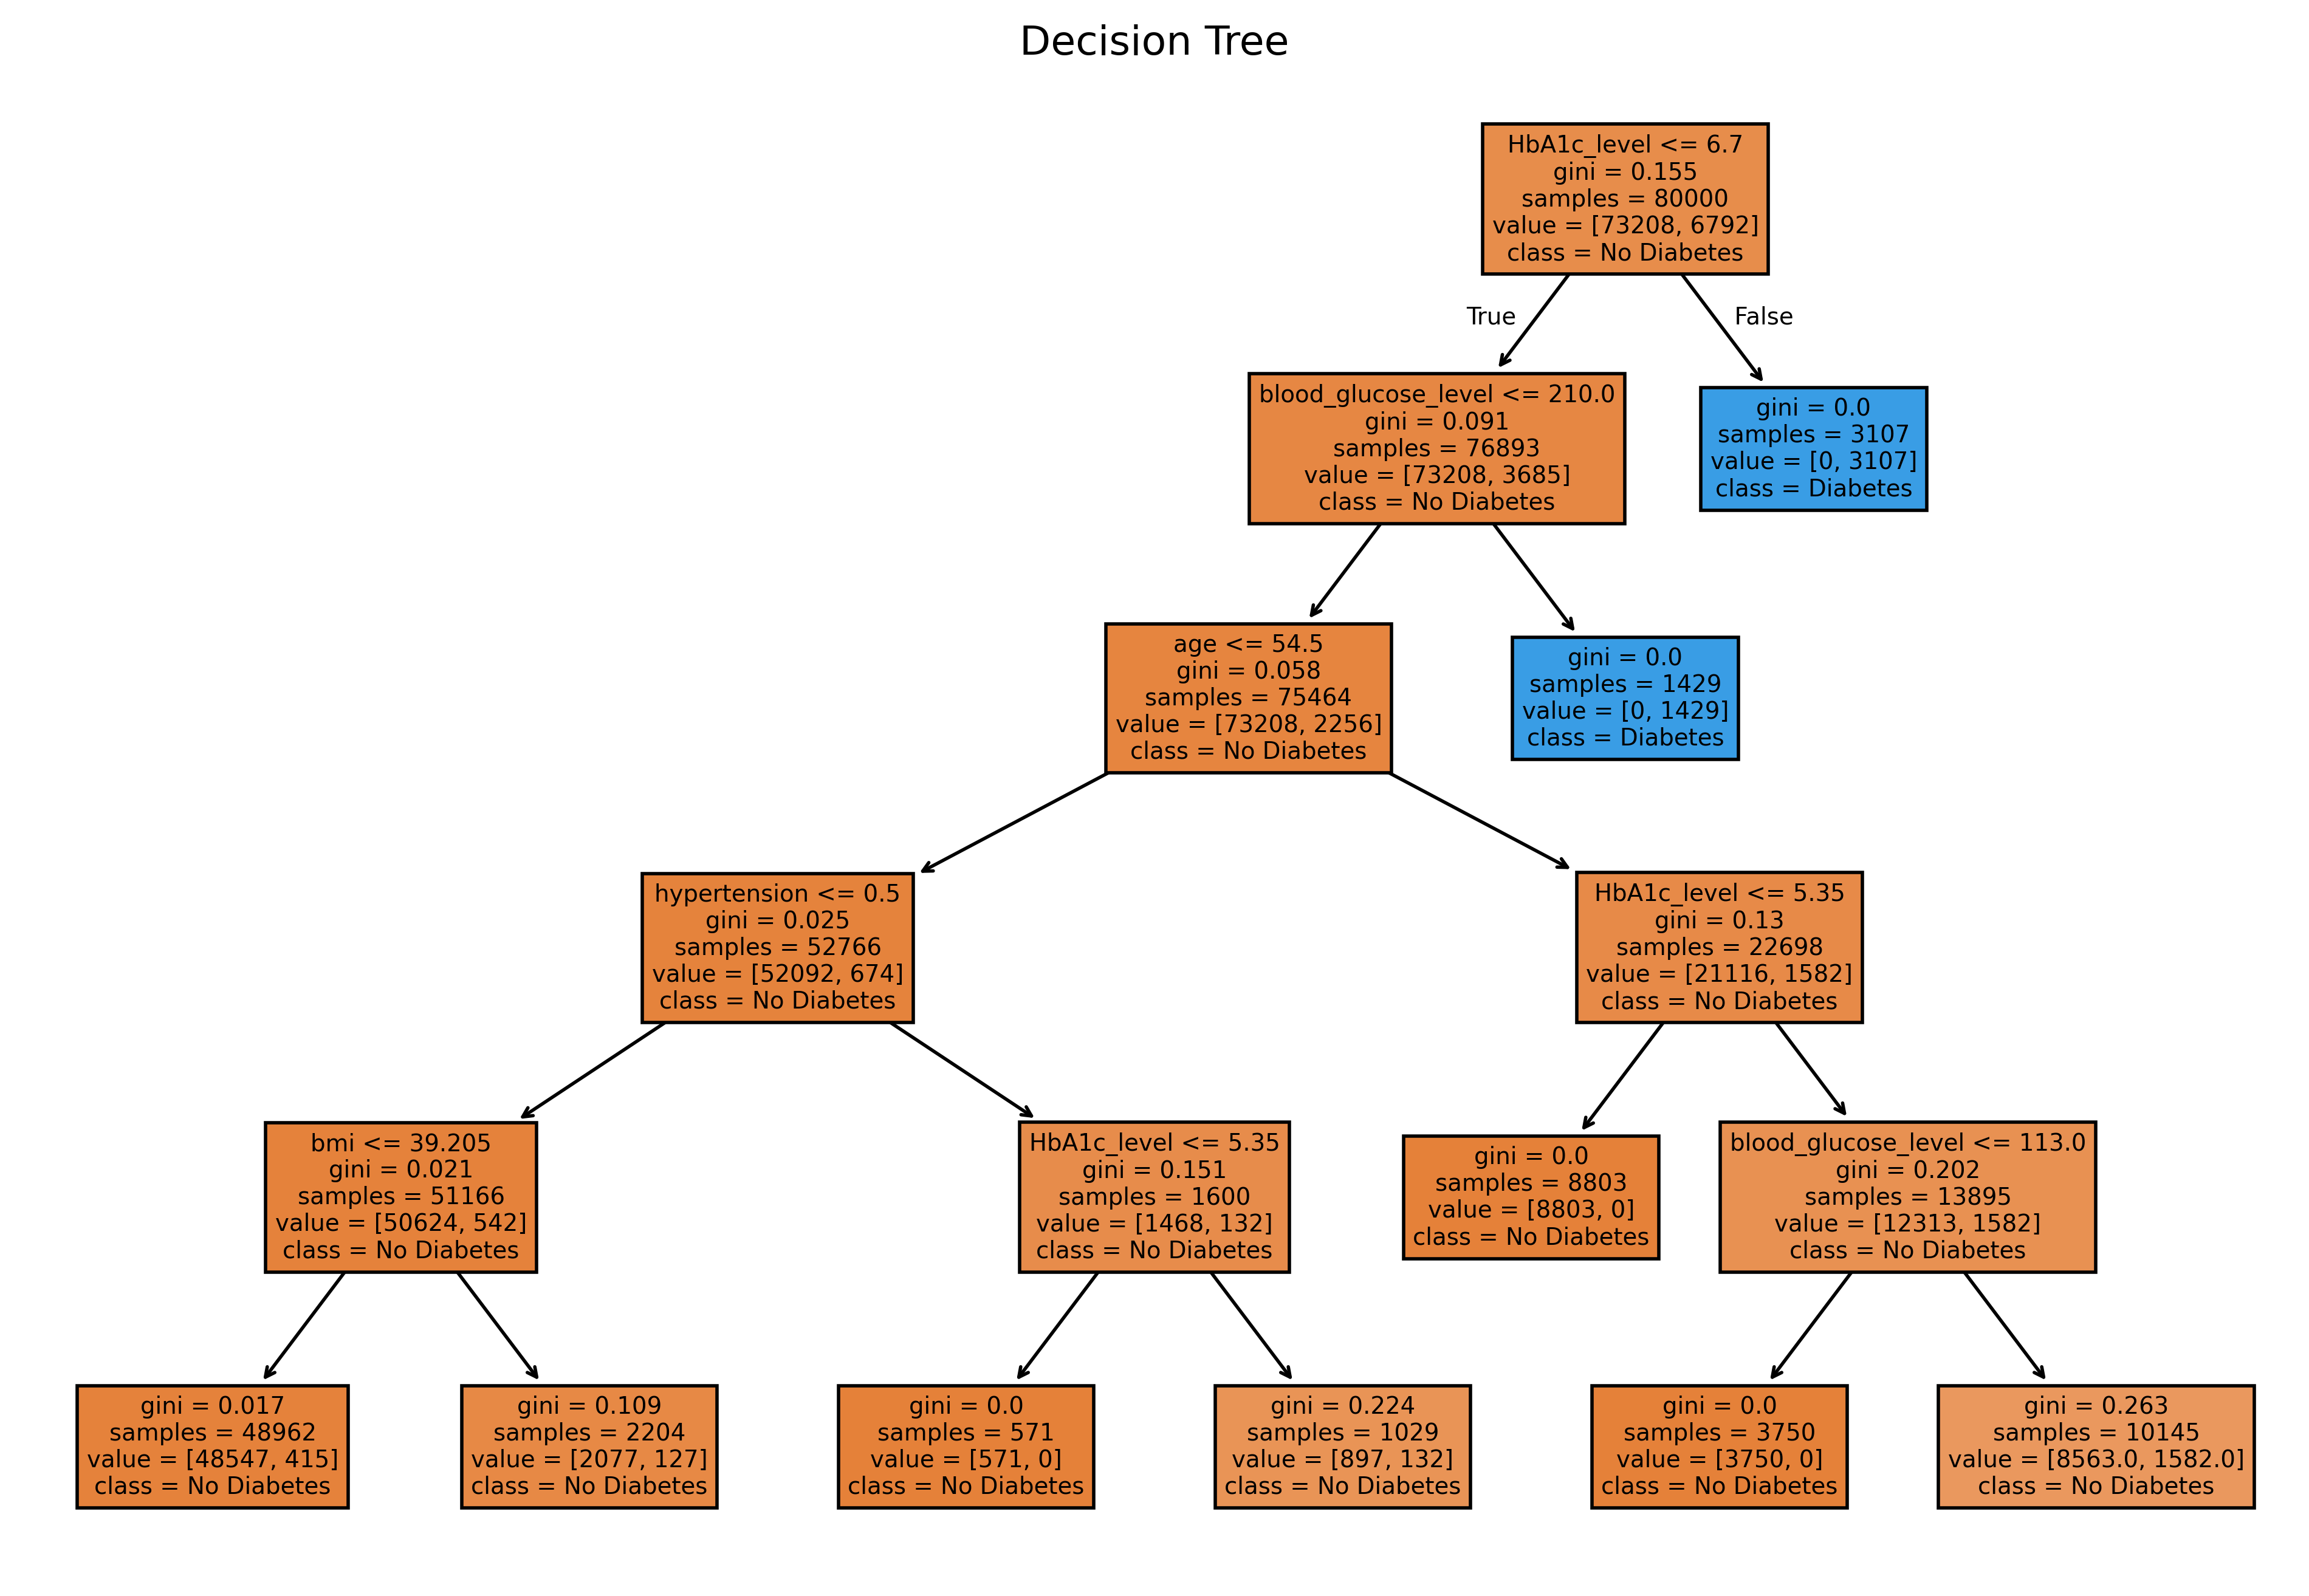

In [23]:
# Xây dựng cây quyết định

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Huấn luyện cây quyết định
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred_dt = dt.predict(X_test)

# Vẽ cây quyết định
plt.figure(figsize=(12,8))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.title("Decision Tree")
plt.show()

In [24]:
#  Xây dựng mô hình Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [25]:
# Vẽ biểu đồ đánh giá mô hình Random Forest

import numpy as np
from sklearn.model_selection import GridSearchCV
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Ví dụ: đánh giá với số cây khác nhau
rf_params = {'n_estimators': list(range(10, 110, 10))}
cv_rf = GridSearchCV(rf, param_grid=rf_params, scoring='roc_auc', cv=4,
                     return_train_score=True, error_score='raise', verbose=1)
cv_rf.fit(X_train, y_train)

cv_rf_results_df = pd.DataFrame(cv_rf.cv_results_)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


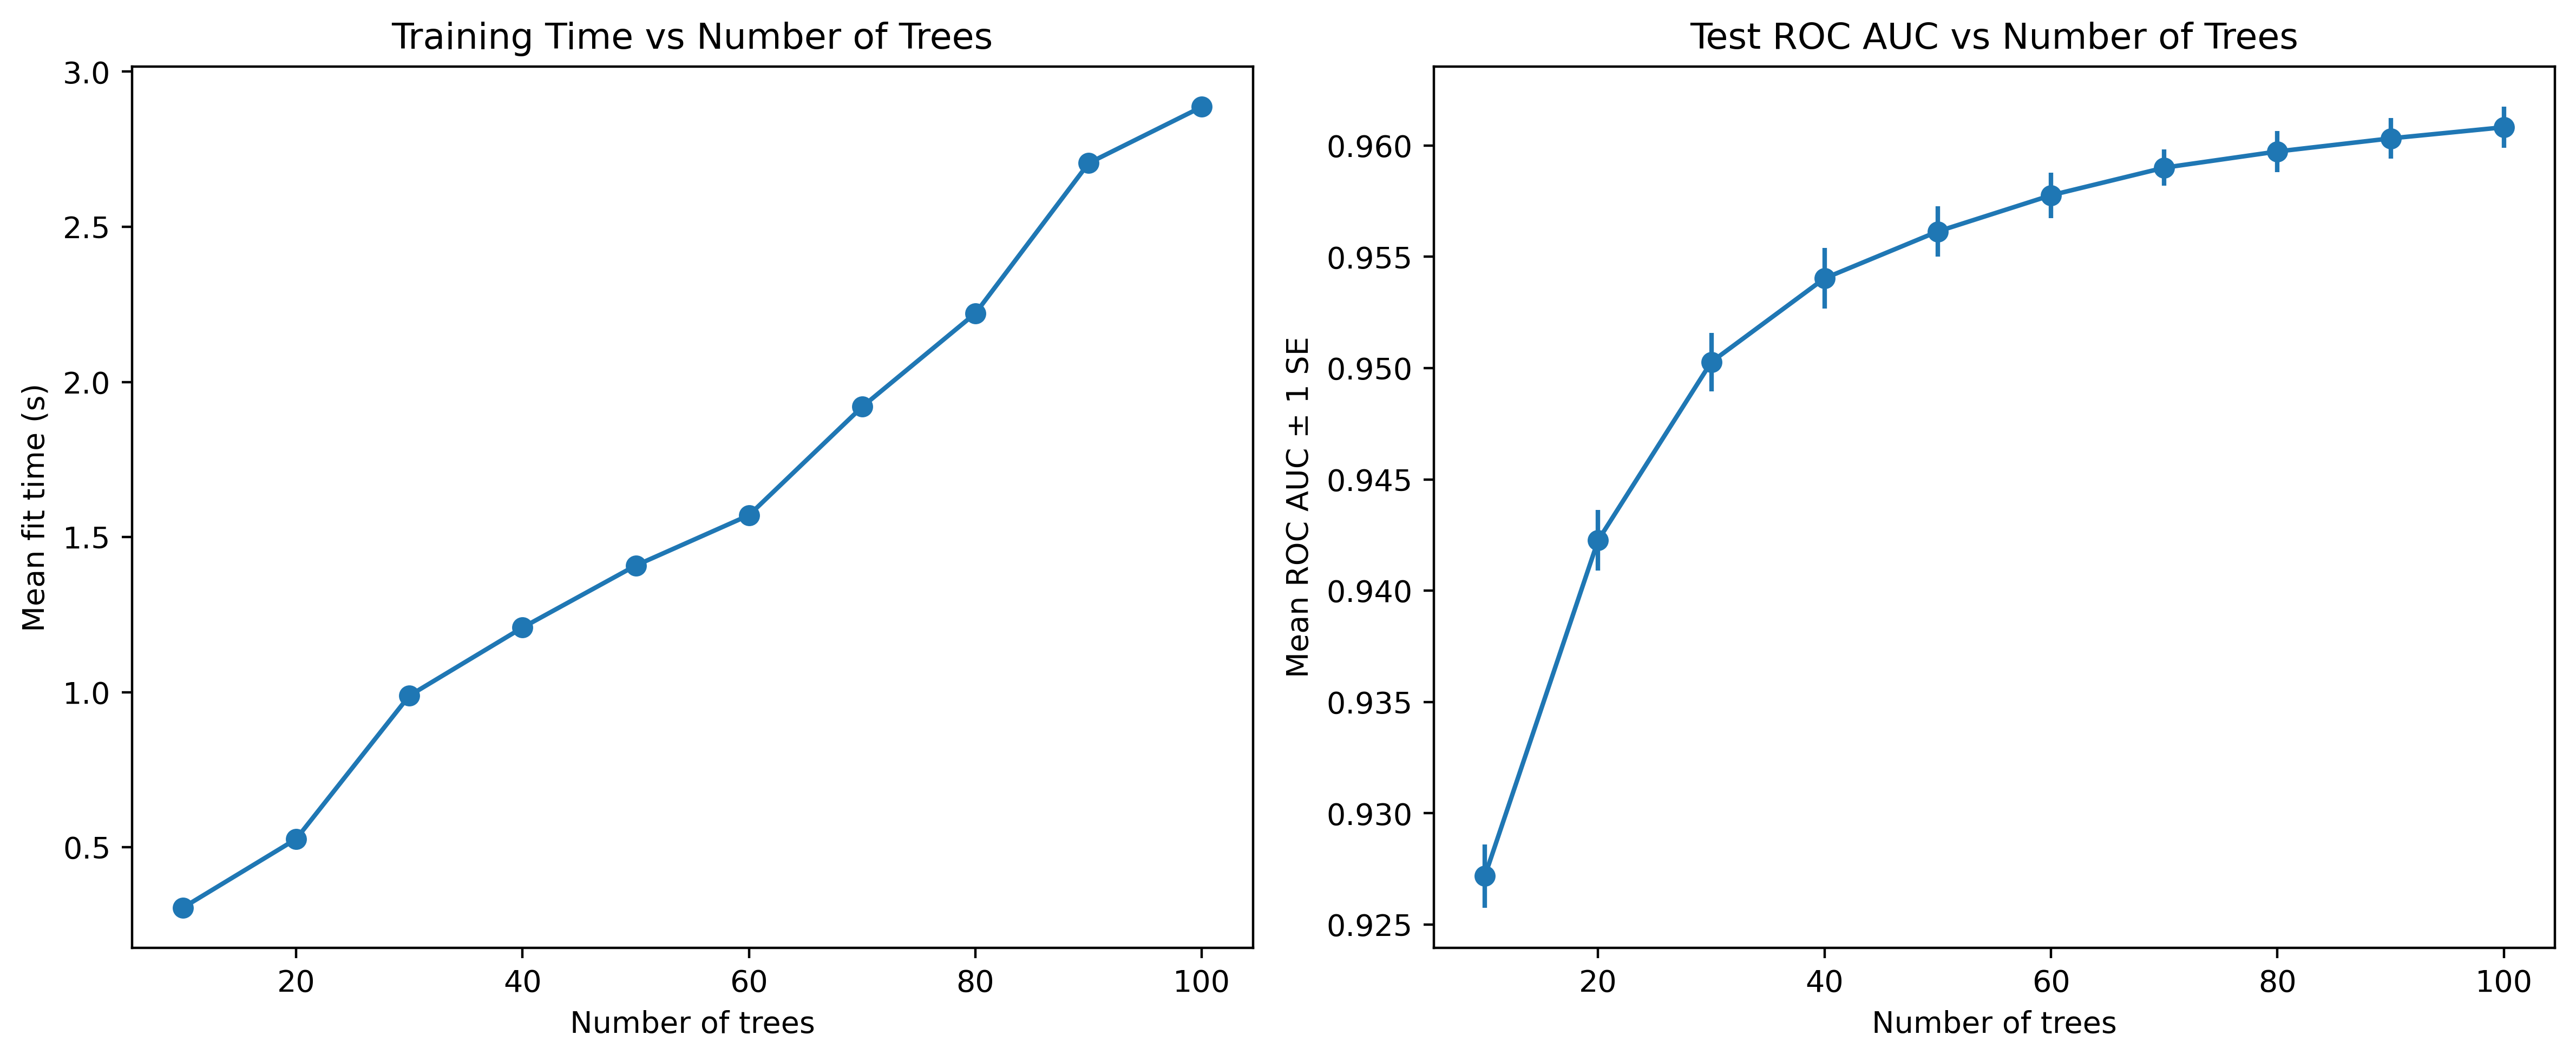

In [26]:
# Biểu đồ thời gian huấn luyện
axs[0].plot(cv_rf_results_df['param_n_estimators'], cv_rf_results_df['mean_fit_time'], '-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (s)')
axs[0].set_title('Training Time vs Number of Trees')

# Biểu đồ ROC AUC
axs[1].errorbar(cv_rf_results_df['param_n_estimators'],
                cv_rf_results_df['mean_test_score'],
                yerr=cv_rf_results_df['std_test_score']/np.sqrt(4),
                fmt='-o')
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean ROC AUC ± 1 SE')
axs[1].set_title('Test ROC AUC vs Number of Trees')

plt.tight_layout()
plt.show()

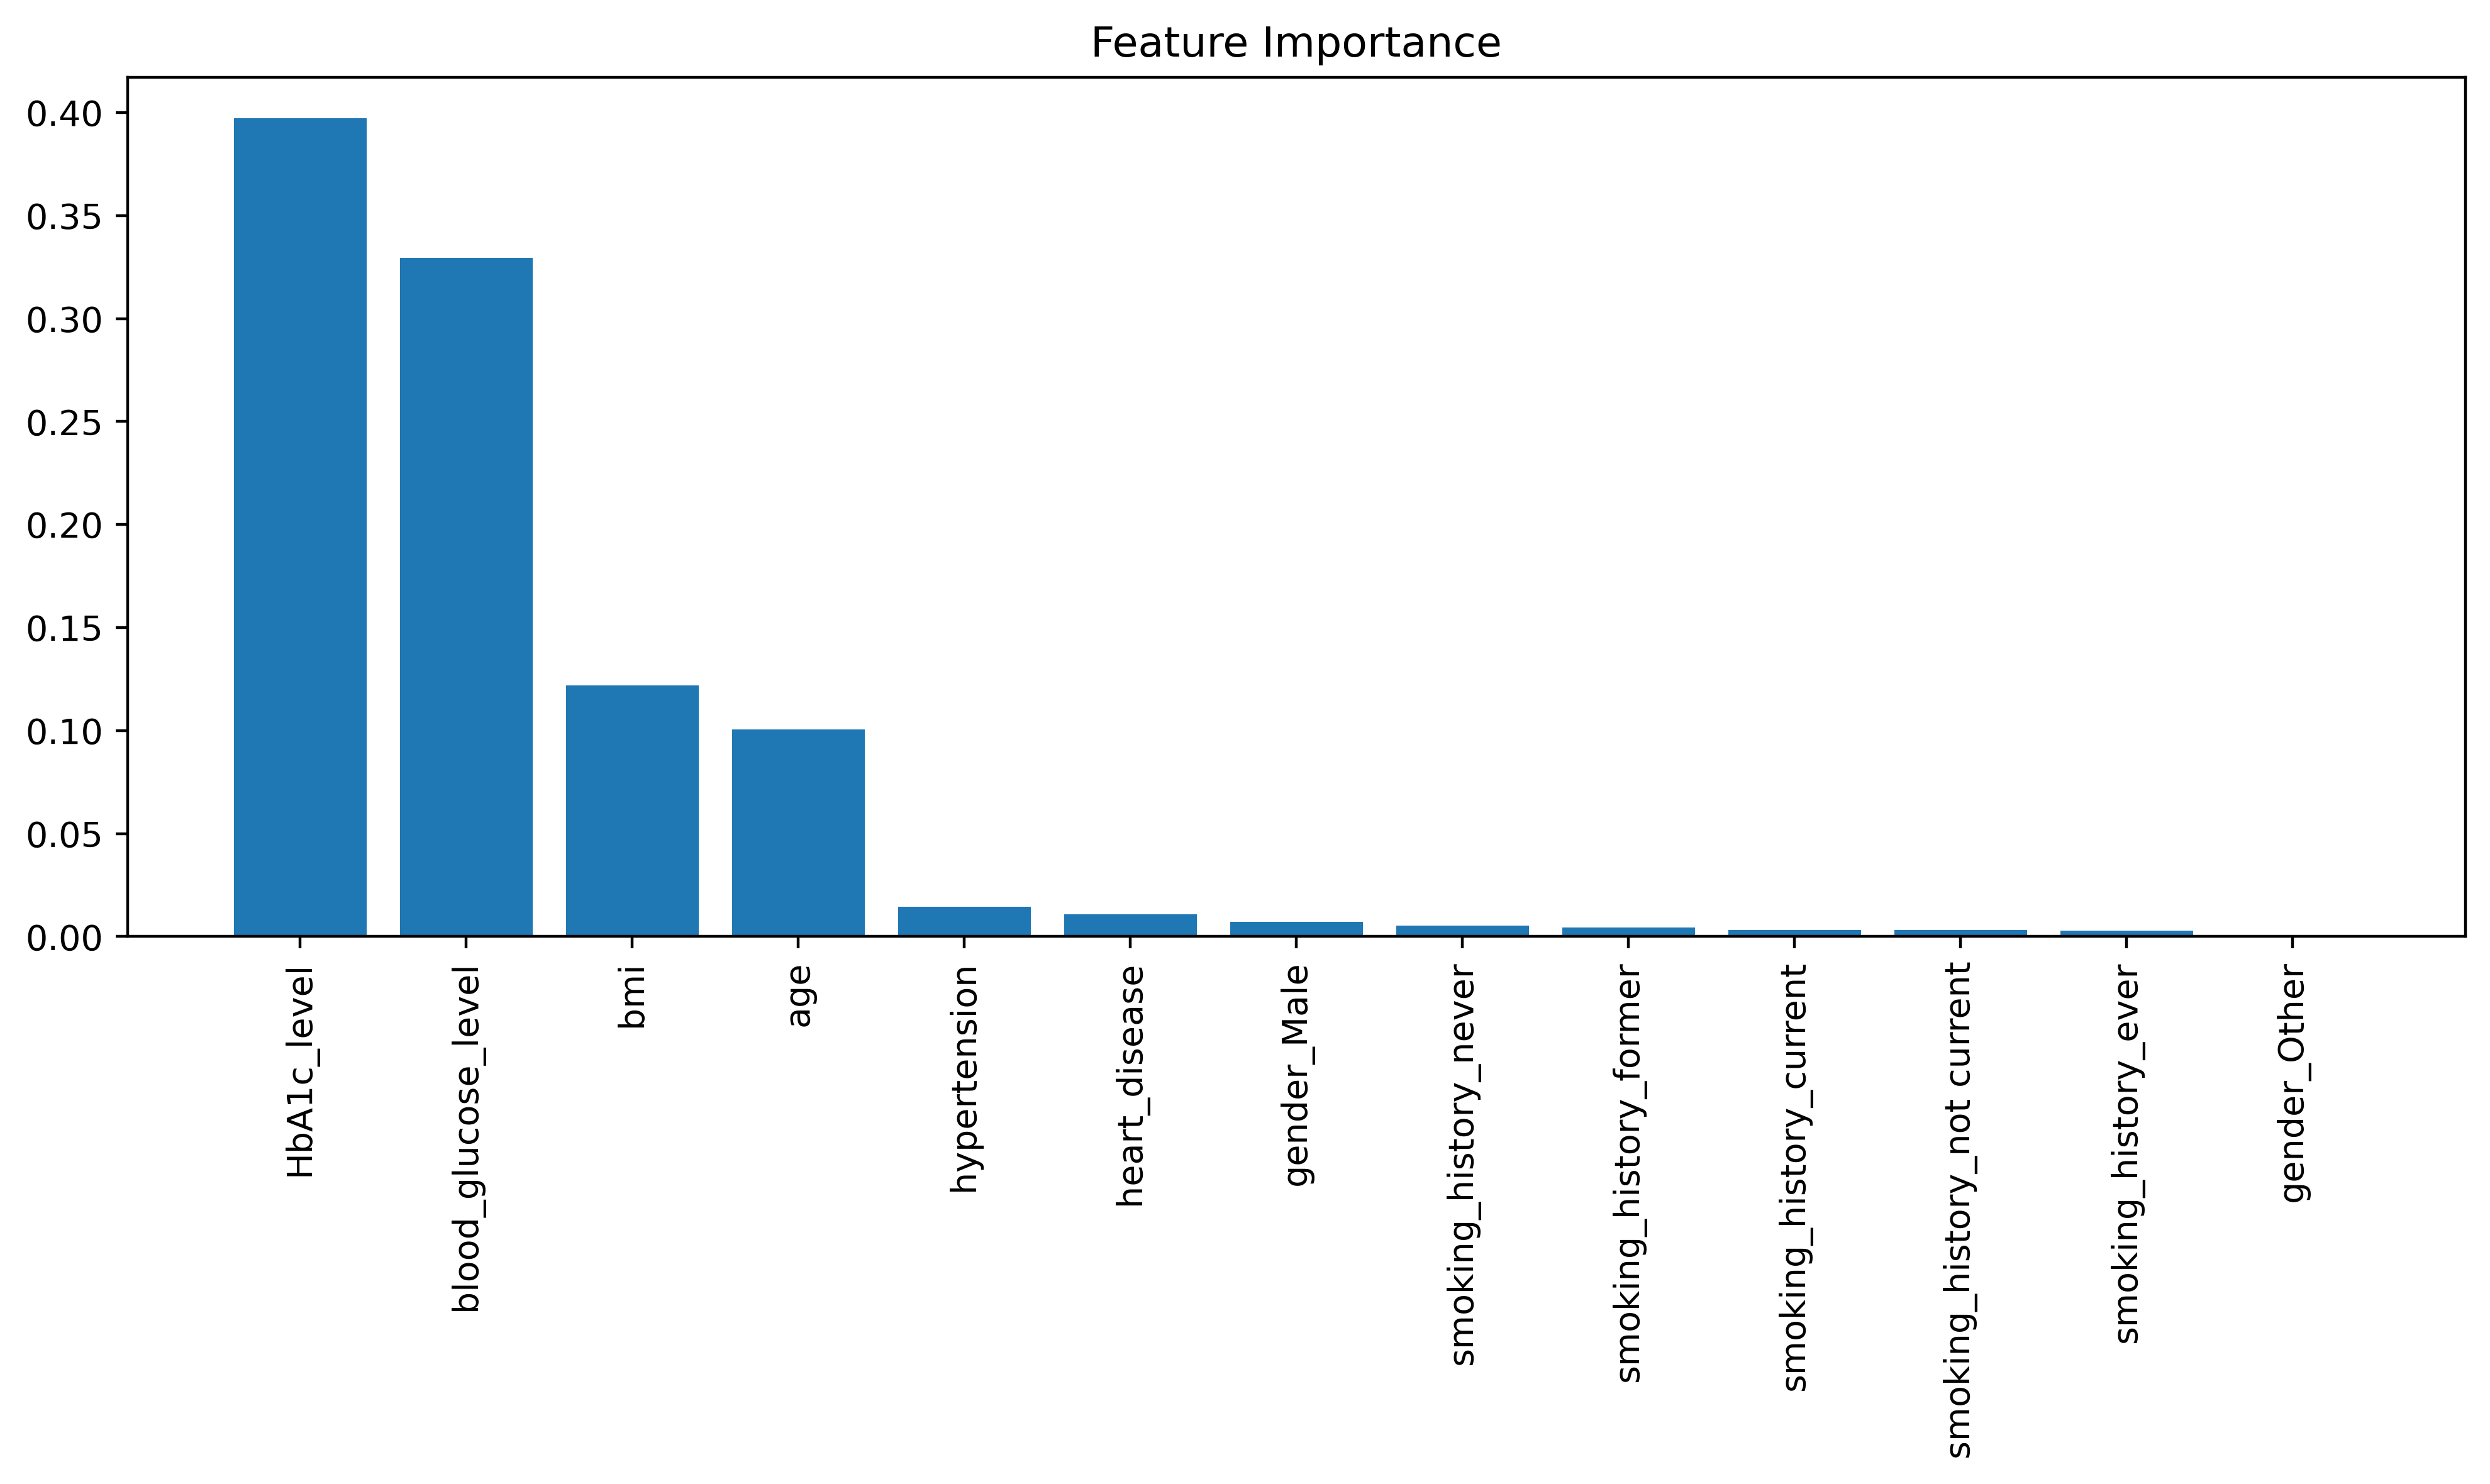

In [27]:
# Biến dự đoán quan trọng
importances = rf.feature_importances_
indices = importances.argsort()[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

## 2.2. GIẢI THUẬT 2: SUPPORT VECTOR MACHINE (SVM)

### Bài toán 1

#### Nhiệm vụ 1: Xây dựng mô hình SVM để phân loại các loài hoa cẩm chướng

In [3]:
# Tải dữ liệu về, nạp dữ liệu, xem thông tin các feature có trong tập dữ liệu và chuẩn bị dữ liệu cho xây dựng mô hình

import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
# Download&Load dữ liệu iris từ datasets của scikit-learn
iris = datasets.load_iris()
# Hiển thị mô ta dữ liệu, chỉ có trong các bộ dữ liệu chuẩn và mở để học tập và nghiên cứu
print(iris.DESCR)
# Từ tập dữ liệu ban đầu, tách lấy ma trận biểu diễn các đặc trưng và nhãn
data = iris.data
target = iris.target
# TODO: Chia dữ liệu và nhãn thành 2 tập dữ liệu huấn luyện và dữ liệu kiểm tra theo tỉ lệ 80:20
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.2, random_state=101)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
# Tạo mô hình SVM với dữ liệu đã chuẩn bị

from sklearn import svm
# khởi tạo mô hình phân lớp
clf = svm.SVC()
# Sử dụng phương thức 'fit' để huấn luyện mô hình với dữ liệu huấn luyện và nhãn huấn luyện
# fit (X,Y) với X là tập các đối tượng, Y là tập nhãn tương ứng của đối tượng.
clf.fit(X_train, y_train)

SVC()

In [5]:
# Đánh giá độ chính xác của mô hình 
# Tính độ chính xác trên tập huấn luyện và tập kiểm tra
train_acc = clf.score(X_train,y_train)
val_acc = clf.score(X_test,y_test)
print('Training accuracy: {}'.format(train_acc))
print('Validation accuracy: {}'.format(val_acc))

Training accuracy: 0.95
Validation accuracy: 0.9666666666666667


In [7]:
# Tìm tham số kernel tối ưu cho mô hình SVM

# best_svm, best_val_acc và best_kernel lần lượt là các biến lưu mô hình tốt nhất,
# độ chính xác cao nhất trên tập kiểm tra và kernel tốt nhất
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_svm = None
best_val_acc = -1
best_kernel = None
# Huấn luyện các mô hình dựa trên dữ liệu huấn luyện và tham số kernel
# Tính toán độ chính xác trên tập huấn luyện và tập kiểm tra để tìm được mô hình tốt nhất
for i in range(4):
 clf = svm.SVC(kernel=kernels[i], probability=True)
 clf.fit(X_train, y_train)
 tmp_val_acc = clf.score(X_test, y_test)
 if (tmp_val_acc > best_val_acc):
     best_val_acc = tmp_val_acc
     best_svm = clf
     best_kernel = kernels[i]
# Hiển thị mô hình tốt nhất cùng với độ chính xác
print("Best validation accuracy : {} with kernel: {}".format(best_val_acc, best_kernel))
# Mô hình tốt nhất của bạn nên có độ chính xác xấp xỉ 86,67%

Best validation accuracy : 1.0 with kernel: linear


### Bài toán 2

#### Nhiệm vụ 1: Tìm hiểu về cách biểu diễn và hiển thị các ảnh từ tập dữ liệu là hình ảnh

In [2]:
# Import thư viện và tải dữ liệu là tập các hình ảnh viết tay từ số 0 đến số 9
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
digits = load_digits(n_class=10)

In [3]:
# Khảo sát thông tin có trong digits

#thông tin toàn bộ dữ liệu đã tải về
digits
#xem thông tin của một hình dưới dạng mảng
digits['data'][0]
#xem thông tin 9 nhãn đầu tiên
digits['target'][0:9]
#xem thông tin của một hình dưới dạng ma trận 8 x 8
digits['data'][0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

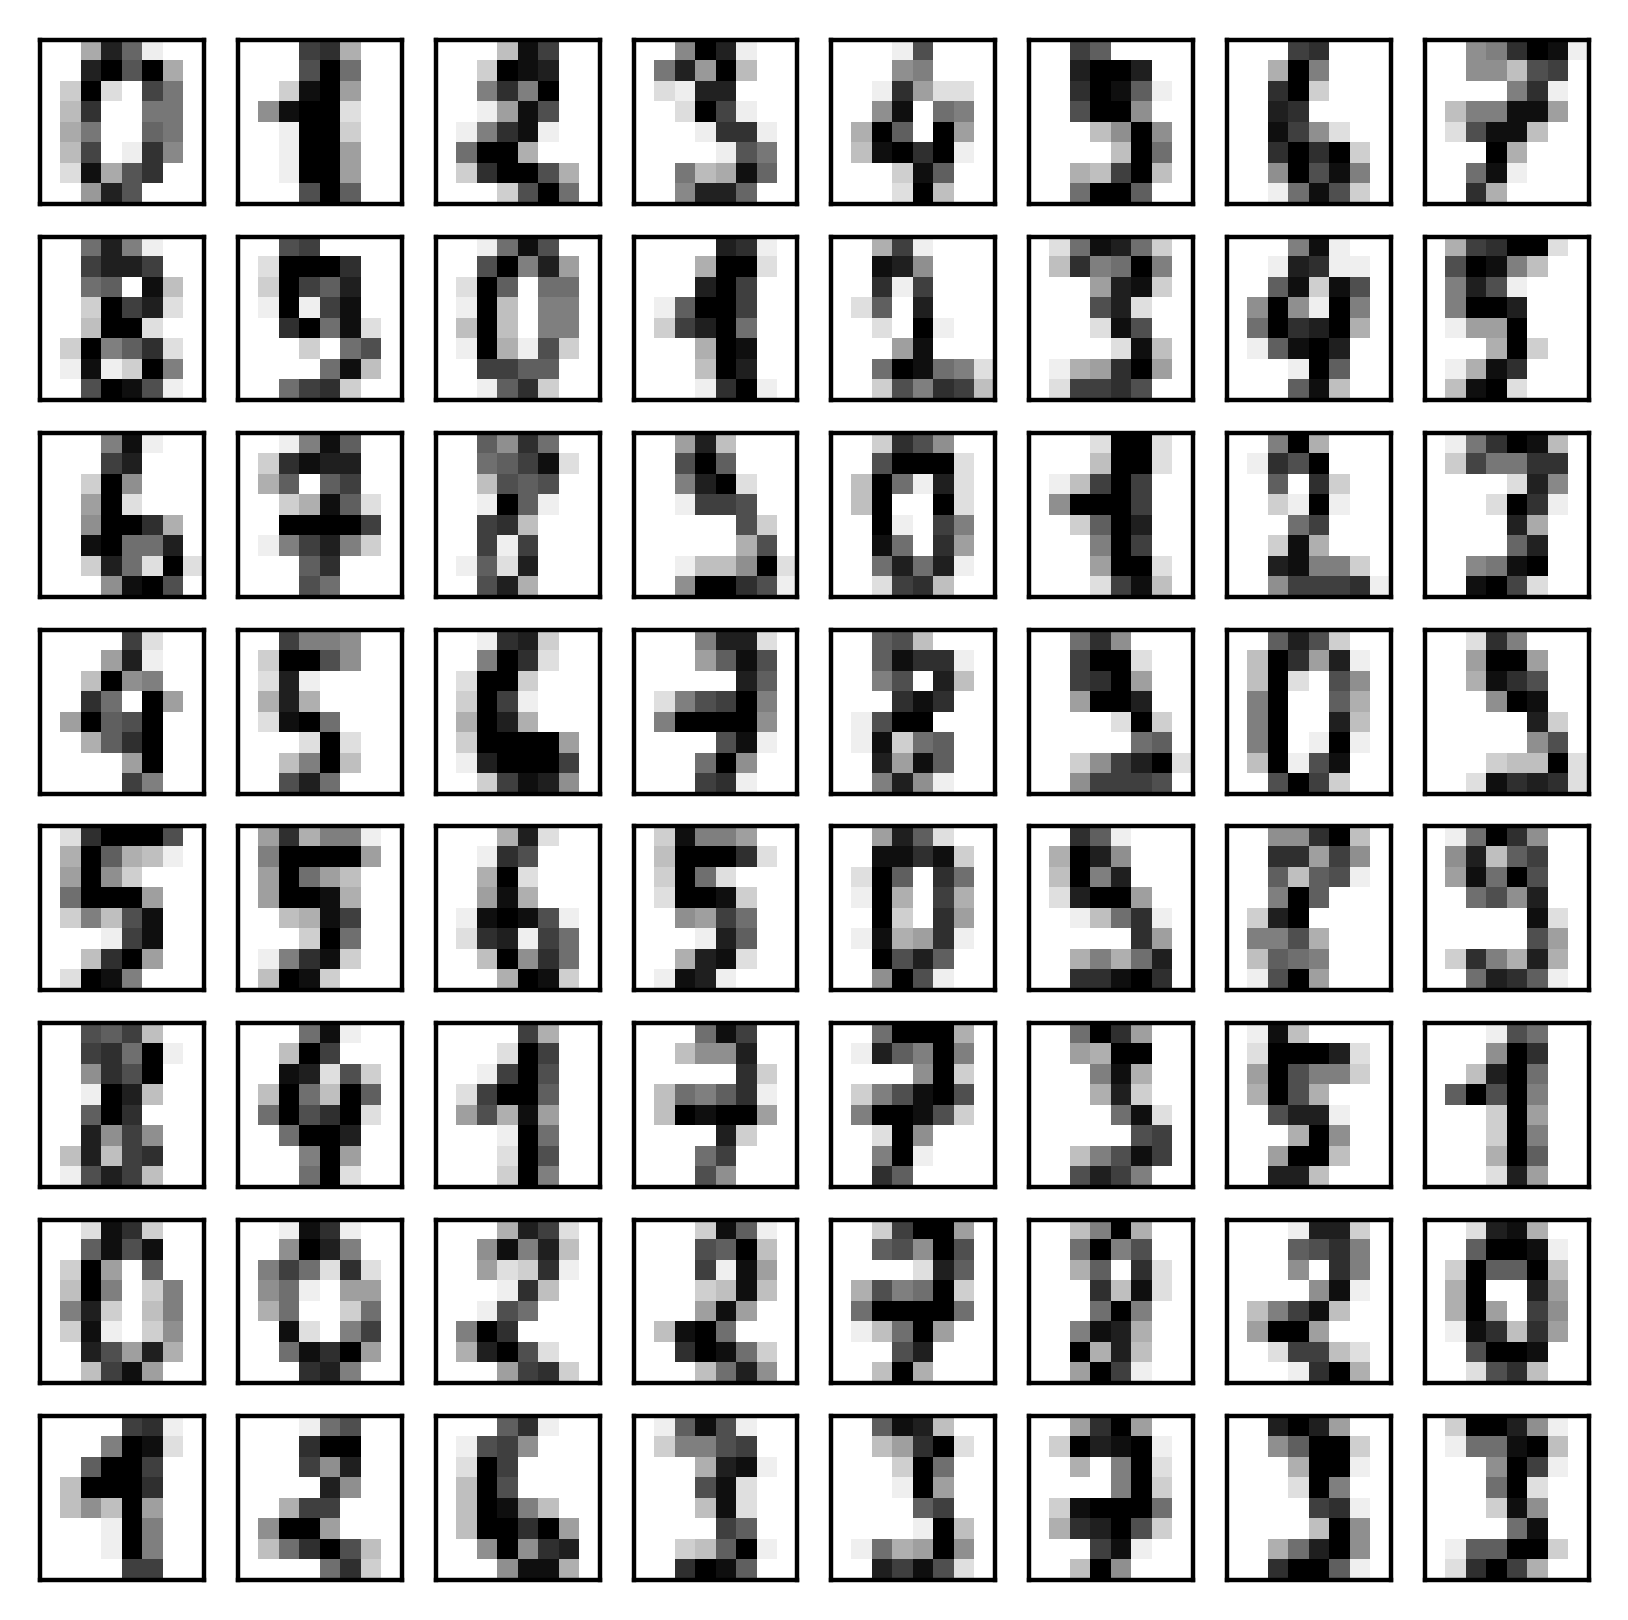

In [19]:
# Vẽ ra hình dựa vào dữ liệu dạng ma trận 8 x 8

# Each Digit is represented in digits.images as a matrix of 8x8 = 64 pixels. Each of the 64 values represent
# a greyscale. The Greyscale are then plotted in the right scale by the imshow method.
fig, ax = plt.subplots(8,8, figsize=(5,5))
for i, axi in enumerate(ax.flat):
    axi.imshow(digits.images[i], cmap='binary')
    axi.set(xticks=[], yticks=[])
plt.show()

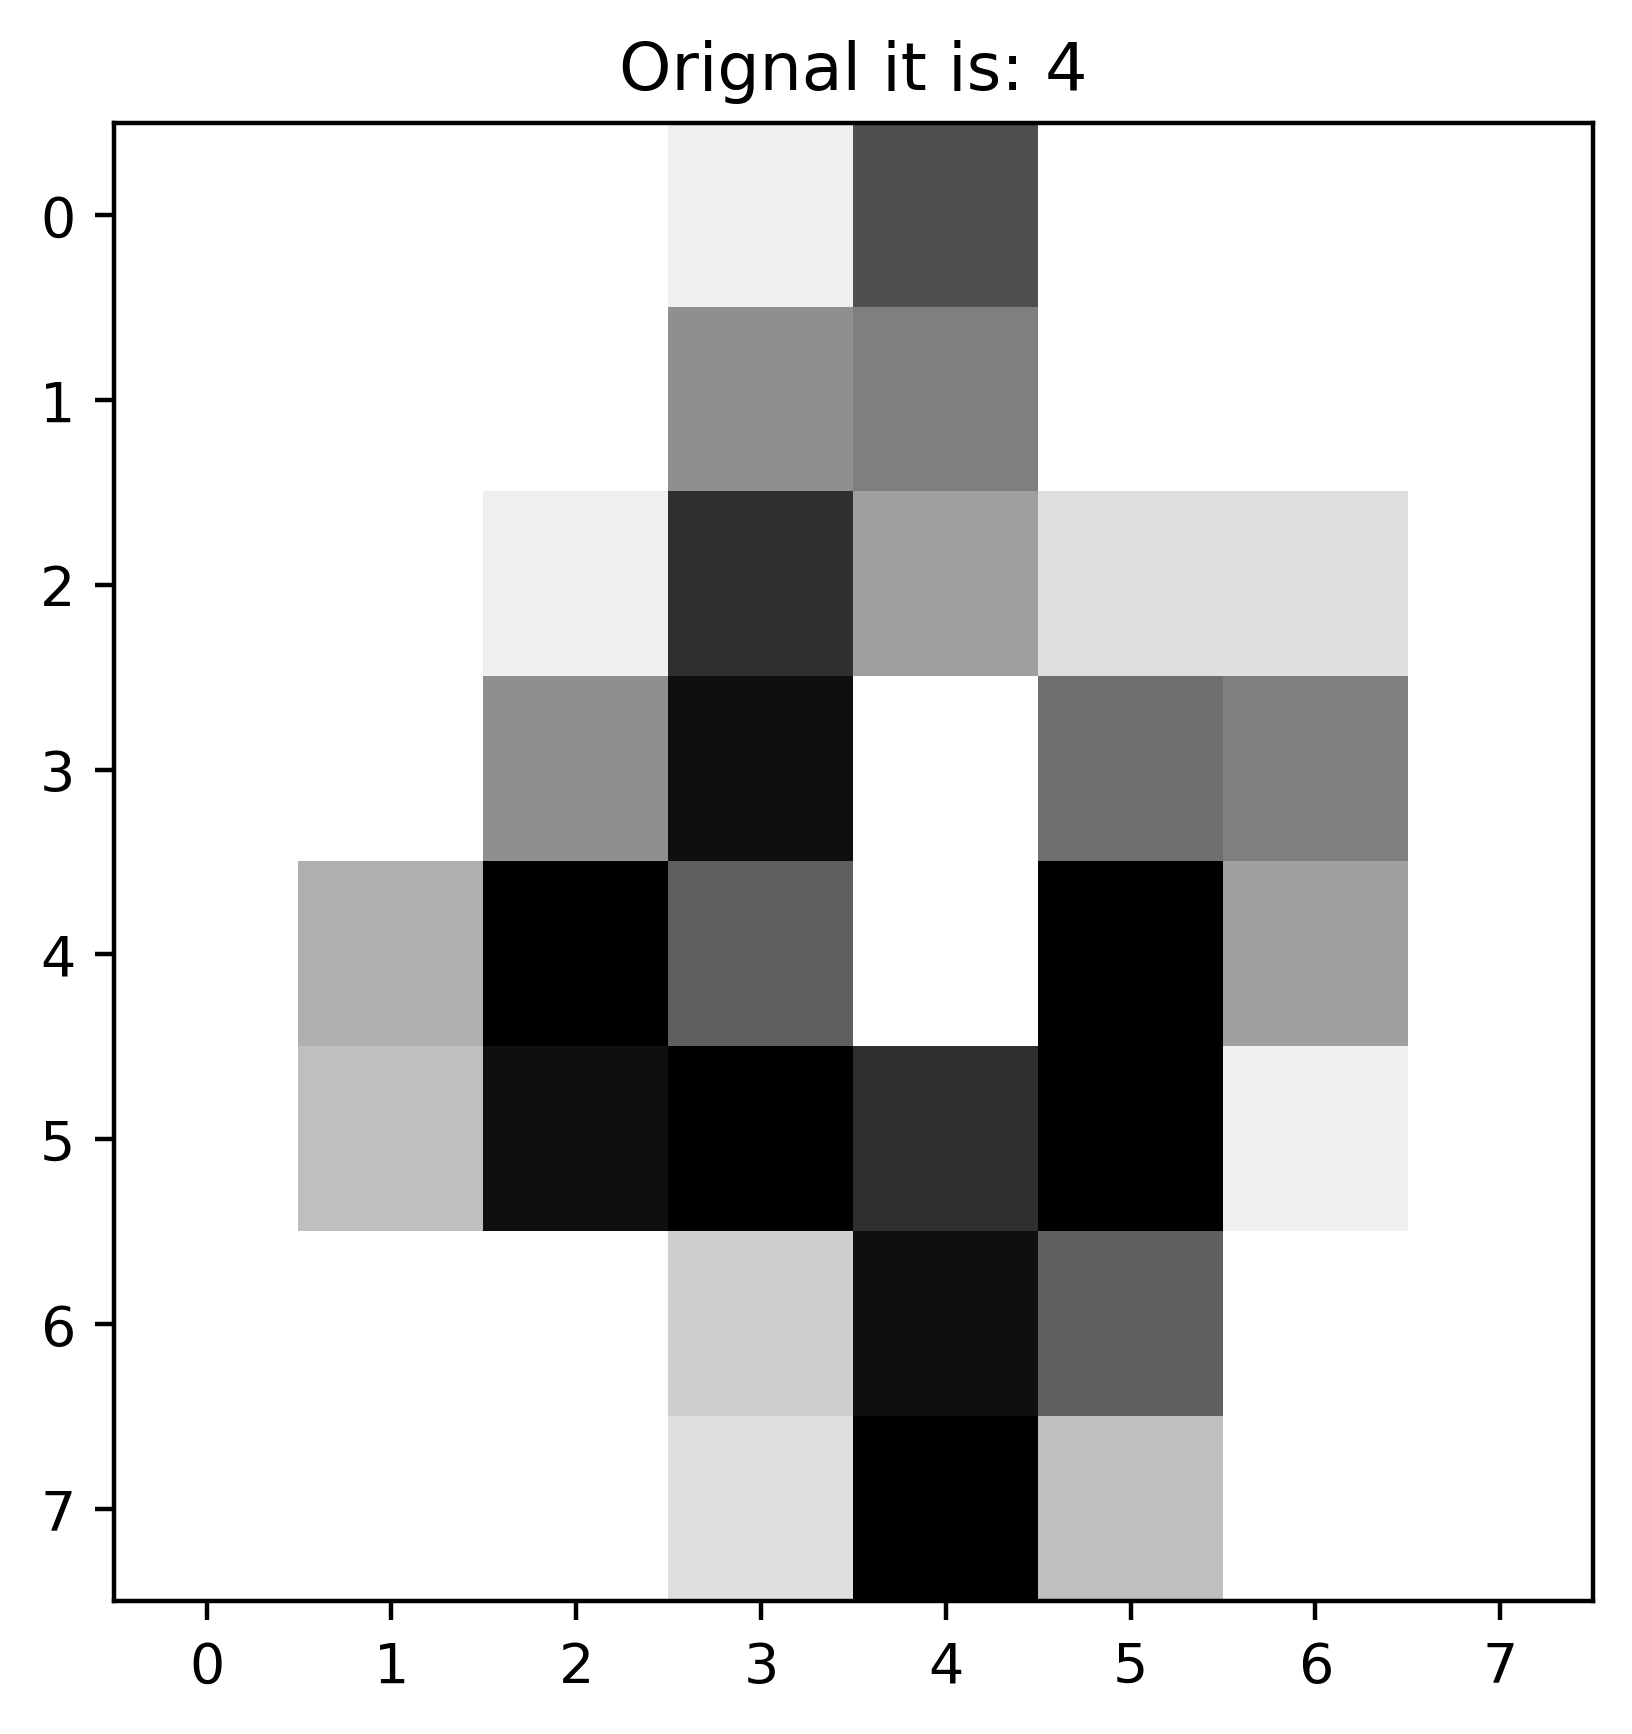

In [18]:
# Vẽ một ảnh từ ma trận 8 x 8

# Hàm vẽ 1 ảnh có kích thước 8 x 8 (ảnh lấy từ ma images)
def view_digit(index):
 plt.imshow(digits.images[index] , cmap = plt.cm.gray_r)
 plt.title('Orignal it is: '+ str(digits.target[index]))
 plt.show()
# vẽ ảnh ở vị trí thứ 4
view_digit(4)

#### Nhiệm vụ 2: Xây dựng mô hình SVM để nhận diện chữ viết tay từ 0 – 9

In [4]:
# Thực hiện import các thư viện cần thiết để xây dựng mô hình SVM
# Thực hiện bước 1 của nhiệm vụ 1
from sklearn import svm
main_data = digits['data']
targets = digits['target']
svc = svm.SVC(gamma=0.001 , C = 100)
# GAMMA is a parameter for non linear hyperplanes.
# The higher the gamma value it tries to exactly fit the training data set
# C is the penalty parameter of the error term.
# It controls the trade off between smooth decision boundary and classifying the training points correctly.
svc.fit(main_data[:1500] , targets[:1500])
predictions = svc.predict(main_data[1501:])
# list(zip(predictions , targets[1501:]))

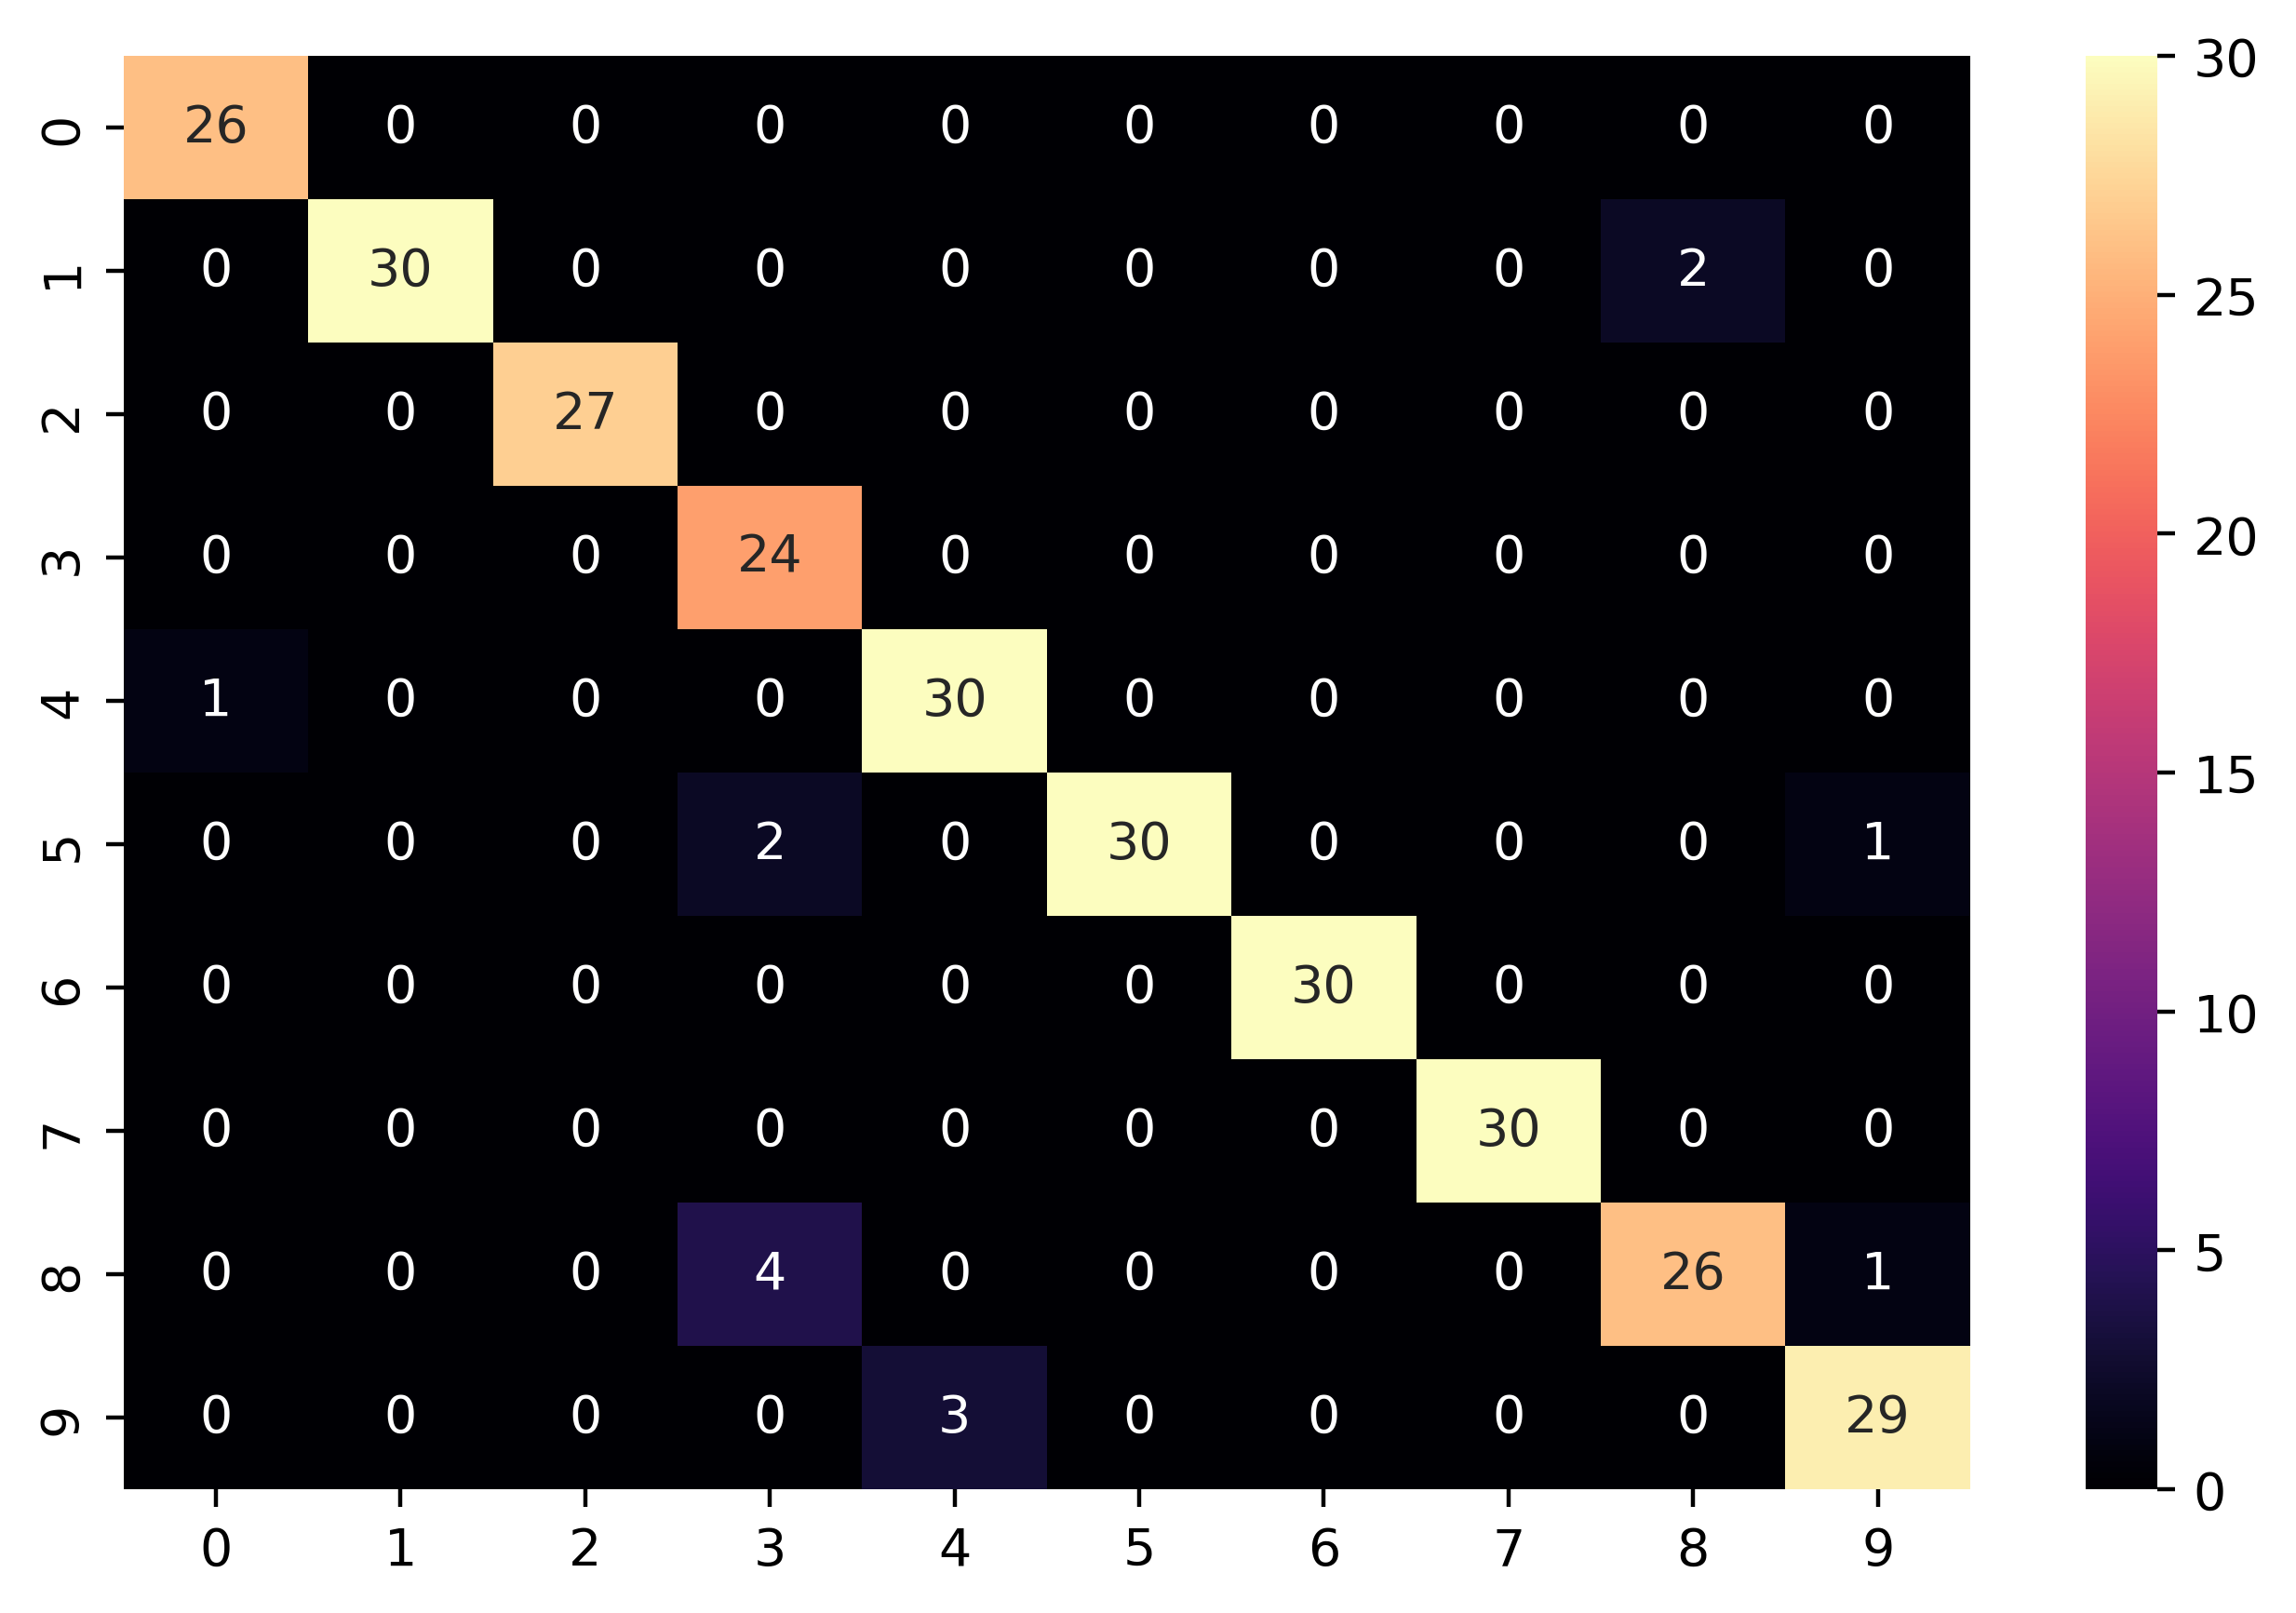

In [12]:
# Đánh giá hiệu quả của mô hình với Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(predictions, targets[1501:])
conf_matrix = pd.DataFrame(data = cm)
plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True,fmt='d',cmap='magma');
plt.show()

In [13]:
# In kết quả dạng văn bản
from sklearn.metrics import classification_report
print(classification_report(predictions, targets[1501:]))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.94      0.97        32
           2       1.00      1.00      1.00        27
           3       0.80      1.00      0.89        24
           4       0.91      0.97      0.94        31
           5       1.00      0.91      0.95        33
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        30
           8       0.93      0.84      0.88        31
           9       0.94      0.91      0.92        32

    accuracy                           0.95       296
   macro avg       0.95      0.96      0.95       296
weighted avg       0.96      0.95      0.95       296



### Bài tập thực hành 1

In [45]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [46]:
# Load dữ liệu
df = pd.read_csv('Data/diabetes_prediction_dataset.csv')

In [47]:
# Tiền xử lý dữ liệu

# Chuyển đổi biến phân loại thành biến giả
df = pd.get_dummies(df, drop_first=True)

In [48]:
# Tách X và y
X = df.drop(columns=['diabetes'])
y = df['diabetes']

# Chia tập huấn luyện và kiểm tra (tỷ lệ 80:20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
from sklearn import svm
# Tạo mô hình phân lớp SVM
model = svm.SVC()

model.fit(X_train, y_train)

SVC()

In [50]:
# Tính độ chính xác trên tập huấn luyện và tập kiểm tra
train_acc = model.score(X_train,y_train)
val_acc = model.score(X_test,y_test)
print('Training accuracy: {}'.format(train_acc))
print('Validation accuracy: {}'.format(val_acc))

Training accuracy: 0.9474125
Validation accuracy: 0.94675


In [51]:
# Dự đoán
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

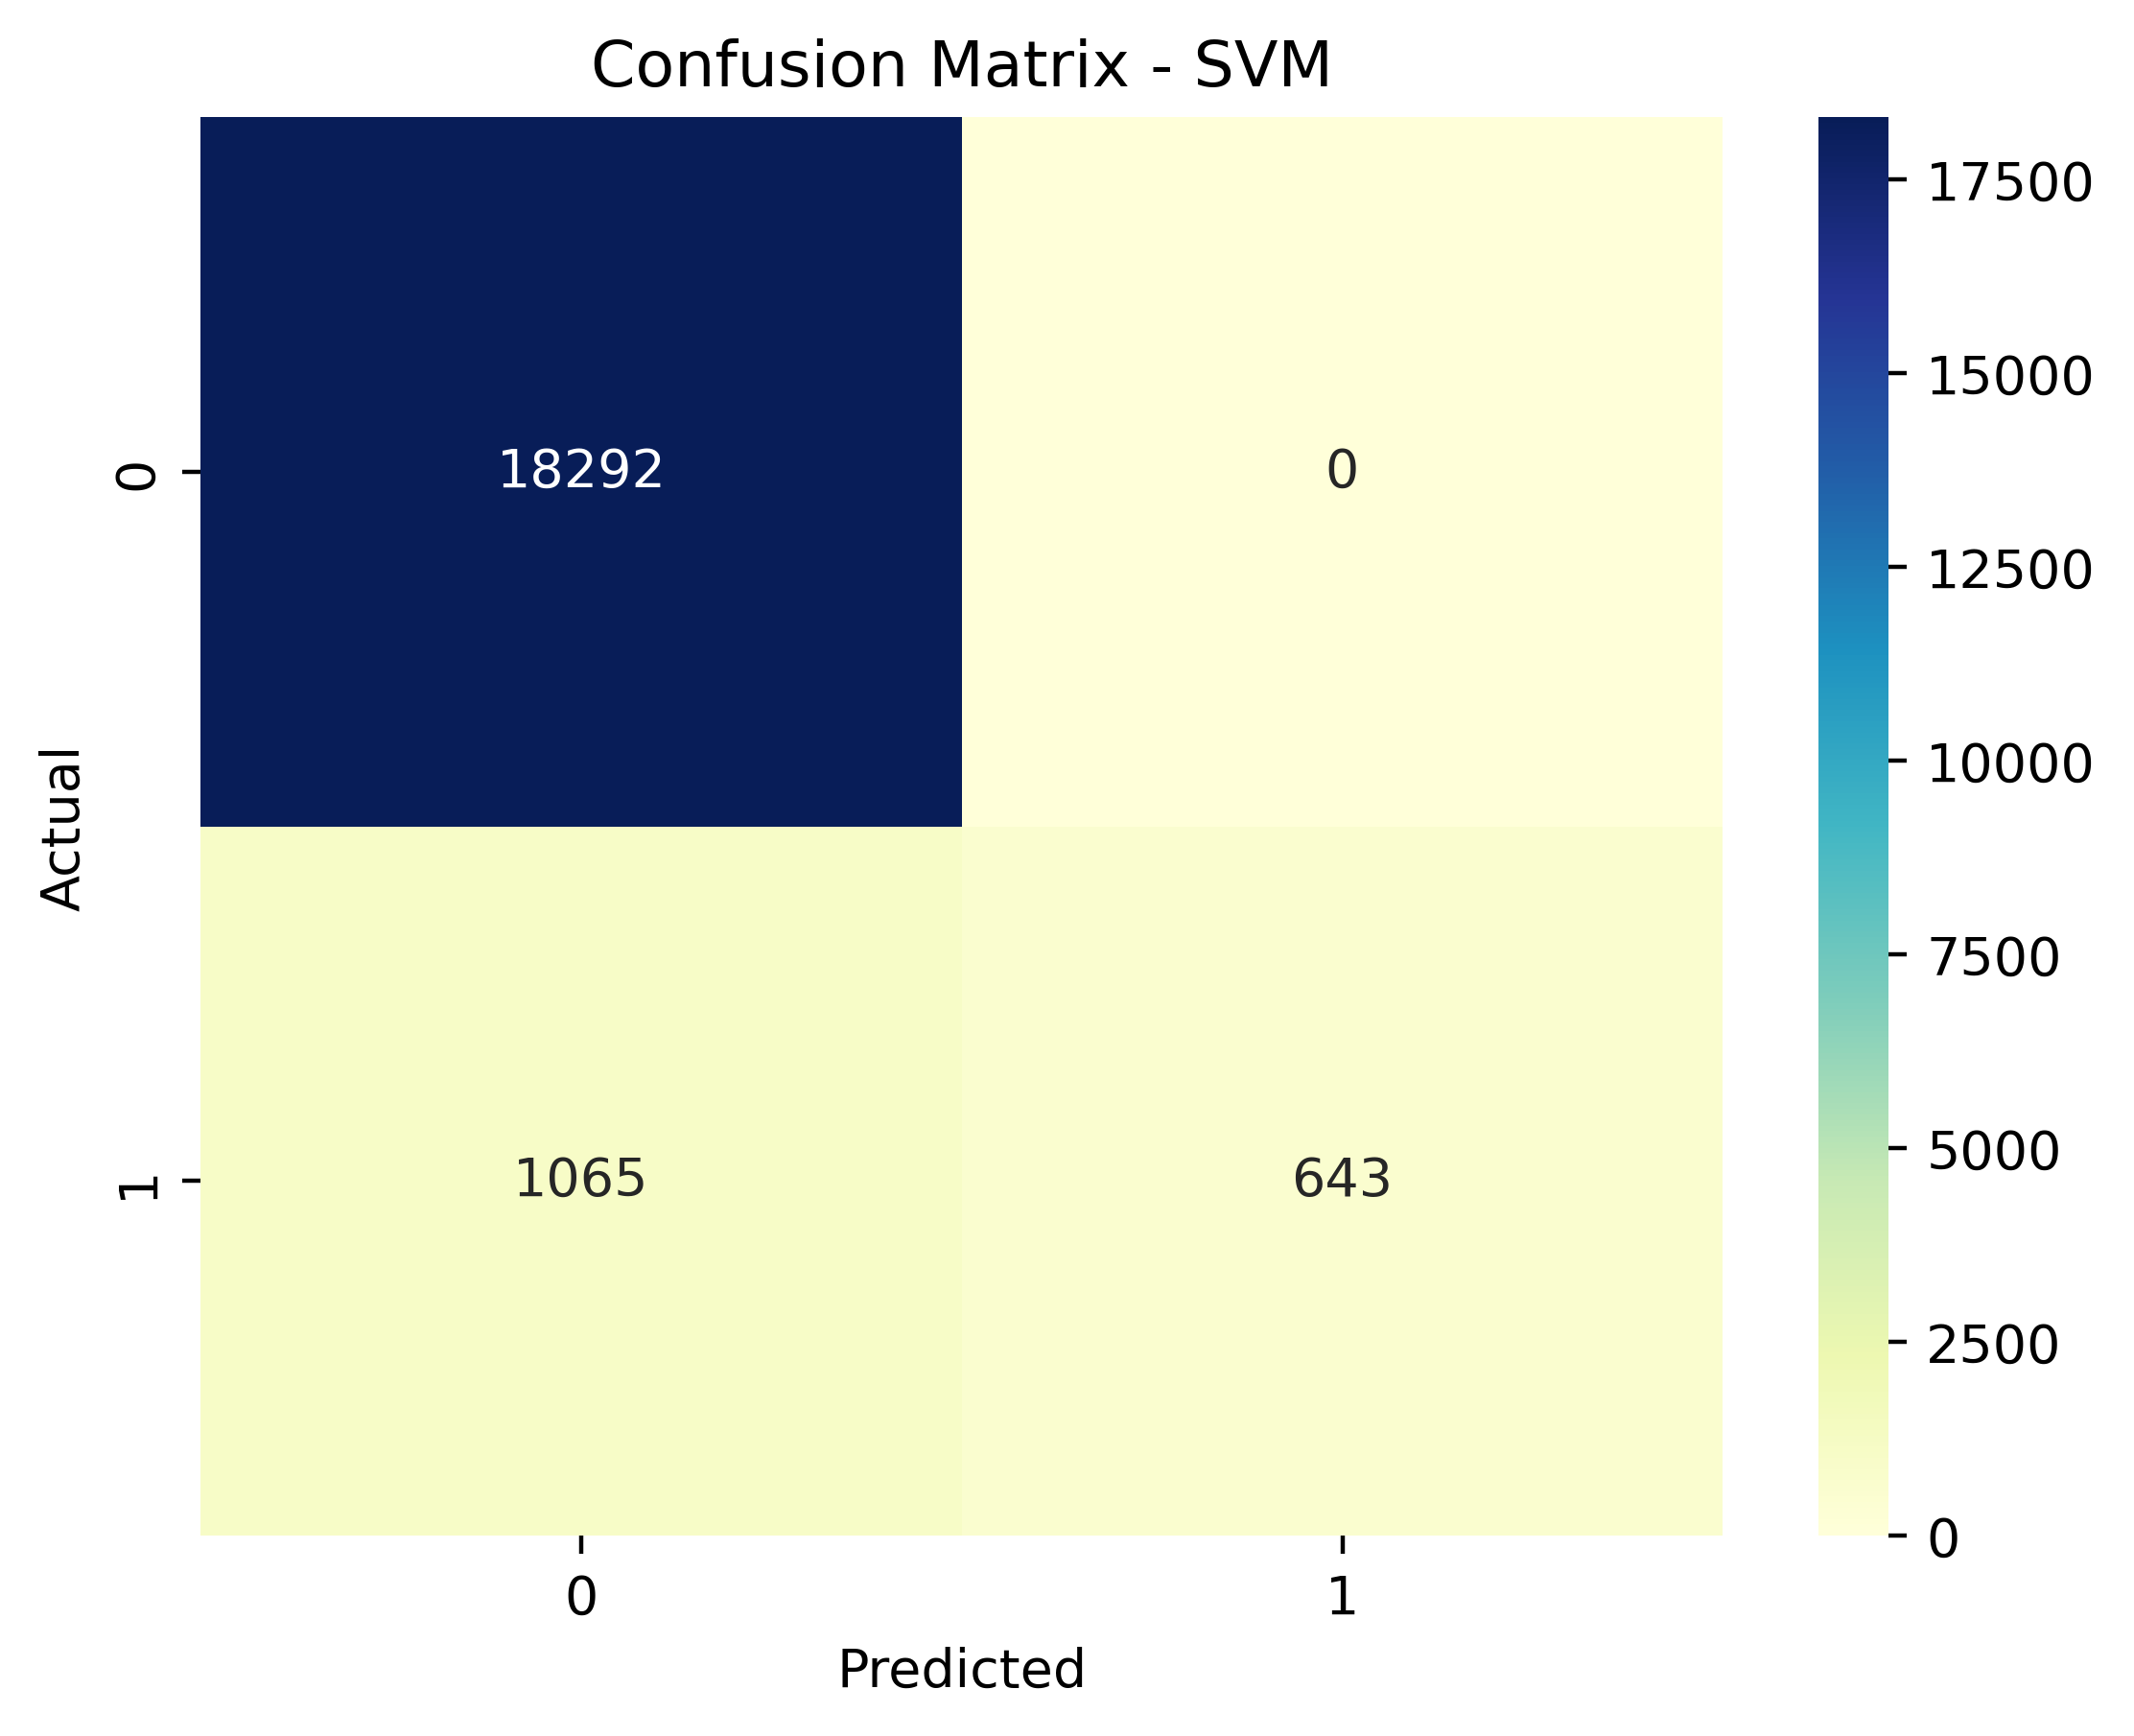

In [52]:
# Vẽ Heatmap ma trận nhầm lẫn
sns.heatmap(pd.DataFrame(cm), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [53]:
# Báo cáo kết quả
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     18292
           1       1.00      0.38      0.55      1708

    accuracy                           0.95     20000
   macro avg       0.97      0.69      0.76     20000
weighted avg       0.95      0.95      0.94     20000



### Bài tập thực hành 2

In [54]:
# Import thư viện
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [55]:
# Nhập dữ liệu
df = pd.read_csv("Data/animal_condition.csv")
df = df.dropna()
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 869 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  869 non-null    object
 1   symptoms1   869 non-null    object
 2   symptoms2   869 non-null    object
 3   symptoms3   869 non-null    object
 4   symptoms4   869 non-null    object
 5   symptoms5   869 non-null    object
 6   Dangerous   869 non-null    object
dtypes: object(7)
memory usage: 54.3+ KB
None
  AnimalName symptoms1             symptoms2 symptoms3    symptoms4  \
0        Dog     Fever              Diarrhea  Vomiting  Weight loss   
1        Dog     Fever              Diarrhea  Coughing    Tiredness   
2        Dog     Fever              Diarrhea  Coughing     Vomiting   
3        Dog     Fever  Difficulty breathing  Coughing     Lethargy   
4        Dog     Fever              Diarrhea  Coughing     Lethargy   

     symptoms5 Dangerous  
0  Dehydration       Yes  
1        Pains

In [56]:
# Mã hóa nhãn
df['Dangerous'] = df['Dangerous'].map({'Yes':1, 'No':0})

# Mã hóa các cột phân loại
label_encoder = LabelEncoder()
df['AnimalName'] = label_encoder.fit_transform(df['AnimalName'])
for col in ['symptoms1', 'symptoms2', 'symptoms3', 'symptoms4', 'symptoms5']:
    df[col] = label_encoder.fit_transform(df[col])

# Kiểm tra lại dữ liệu sau khi mã hóa
print(df.head())

   AnimalName  symptoms1  symptoms2  symptoms3  symptoms4  symptoms5  \
0           6         63         30        179        181         32   
1           6         63         30         31        164        113   
2           6         63         30         31        172          8   
3           6         63         33         31         87        142   
4           6         63         30         31         87         21   

   Dangerous  
0          1  
1          1  
2          1  
3          1  
4          1  


In [57]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra (tỷ lệ 80:20)
X = df.drop(columns=['Dangerous'])
y = df['Dangerous']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# Xác định kernel tốt nhất bằng GridSearchCV

param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10]
}

model = SVC(random_state=42)
grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

Best parameters: {'C': 10, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9812949640287769


In [42]:
# Xây dựng mô hình SVM với kernel tốt nhất
best_svm = grid.best_estimator_

In [43]:
# Tính độ chính xác trên tập huấn luyện và tập kiểm tra
train_acc = best_svm.score(X_train,y_train)
val_acc = best_svm.score(X_test,y_test)
print('Training accuracy: {}'.format(train_acc))
print('Validation accuracy: {}'.format(val_acc))

Training accuracy: 0.9741007194244604
Validation accuracy: 0.9885057471264368


In [22]:
# Dự đoán
y_pred = svm_M.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

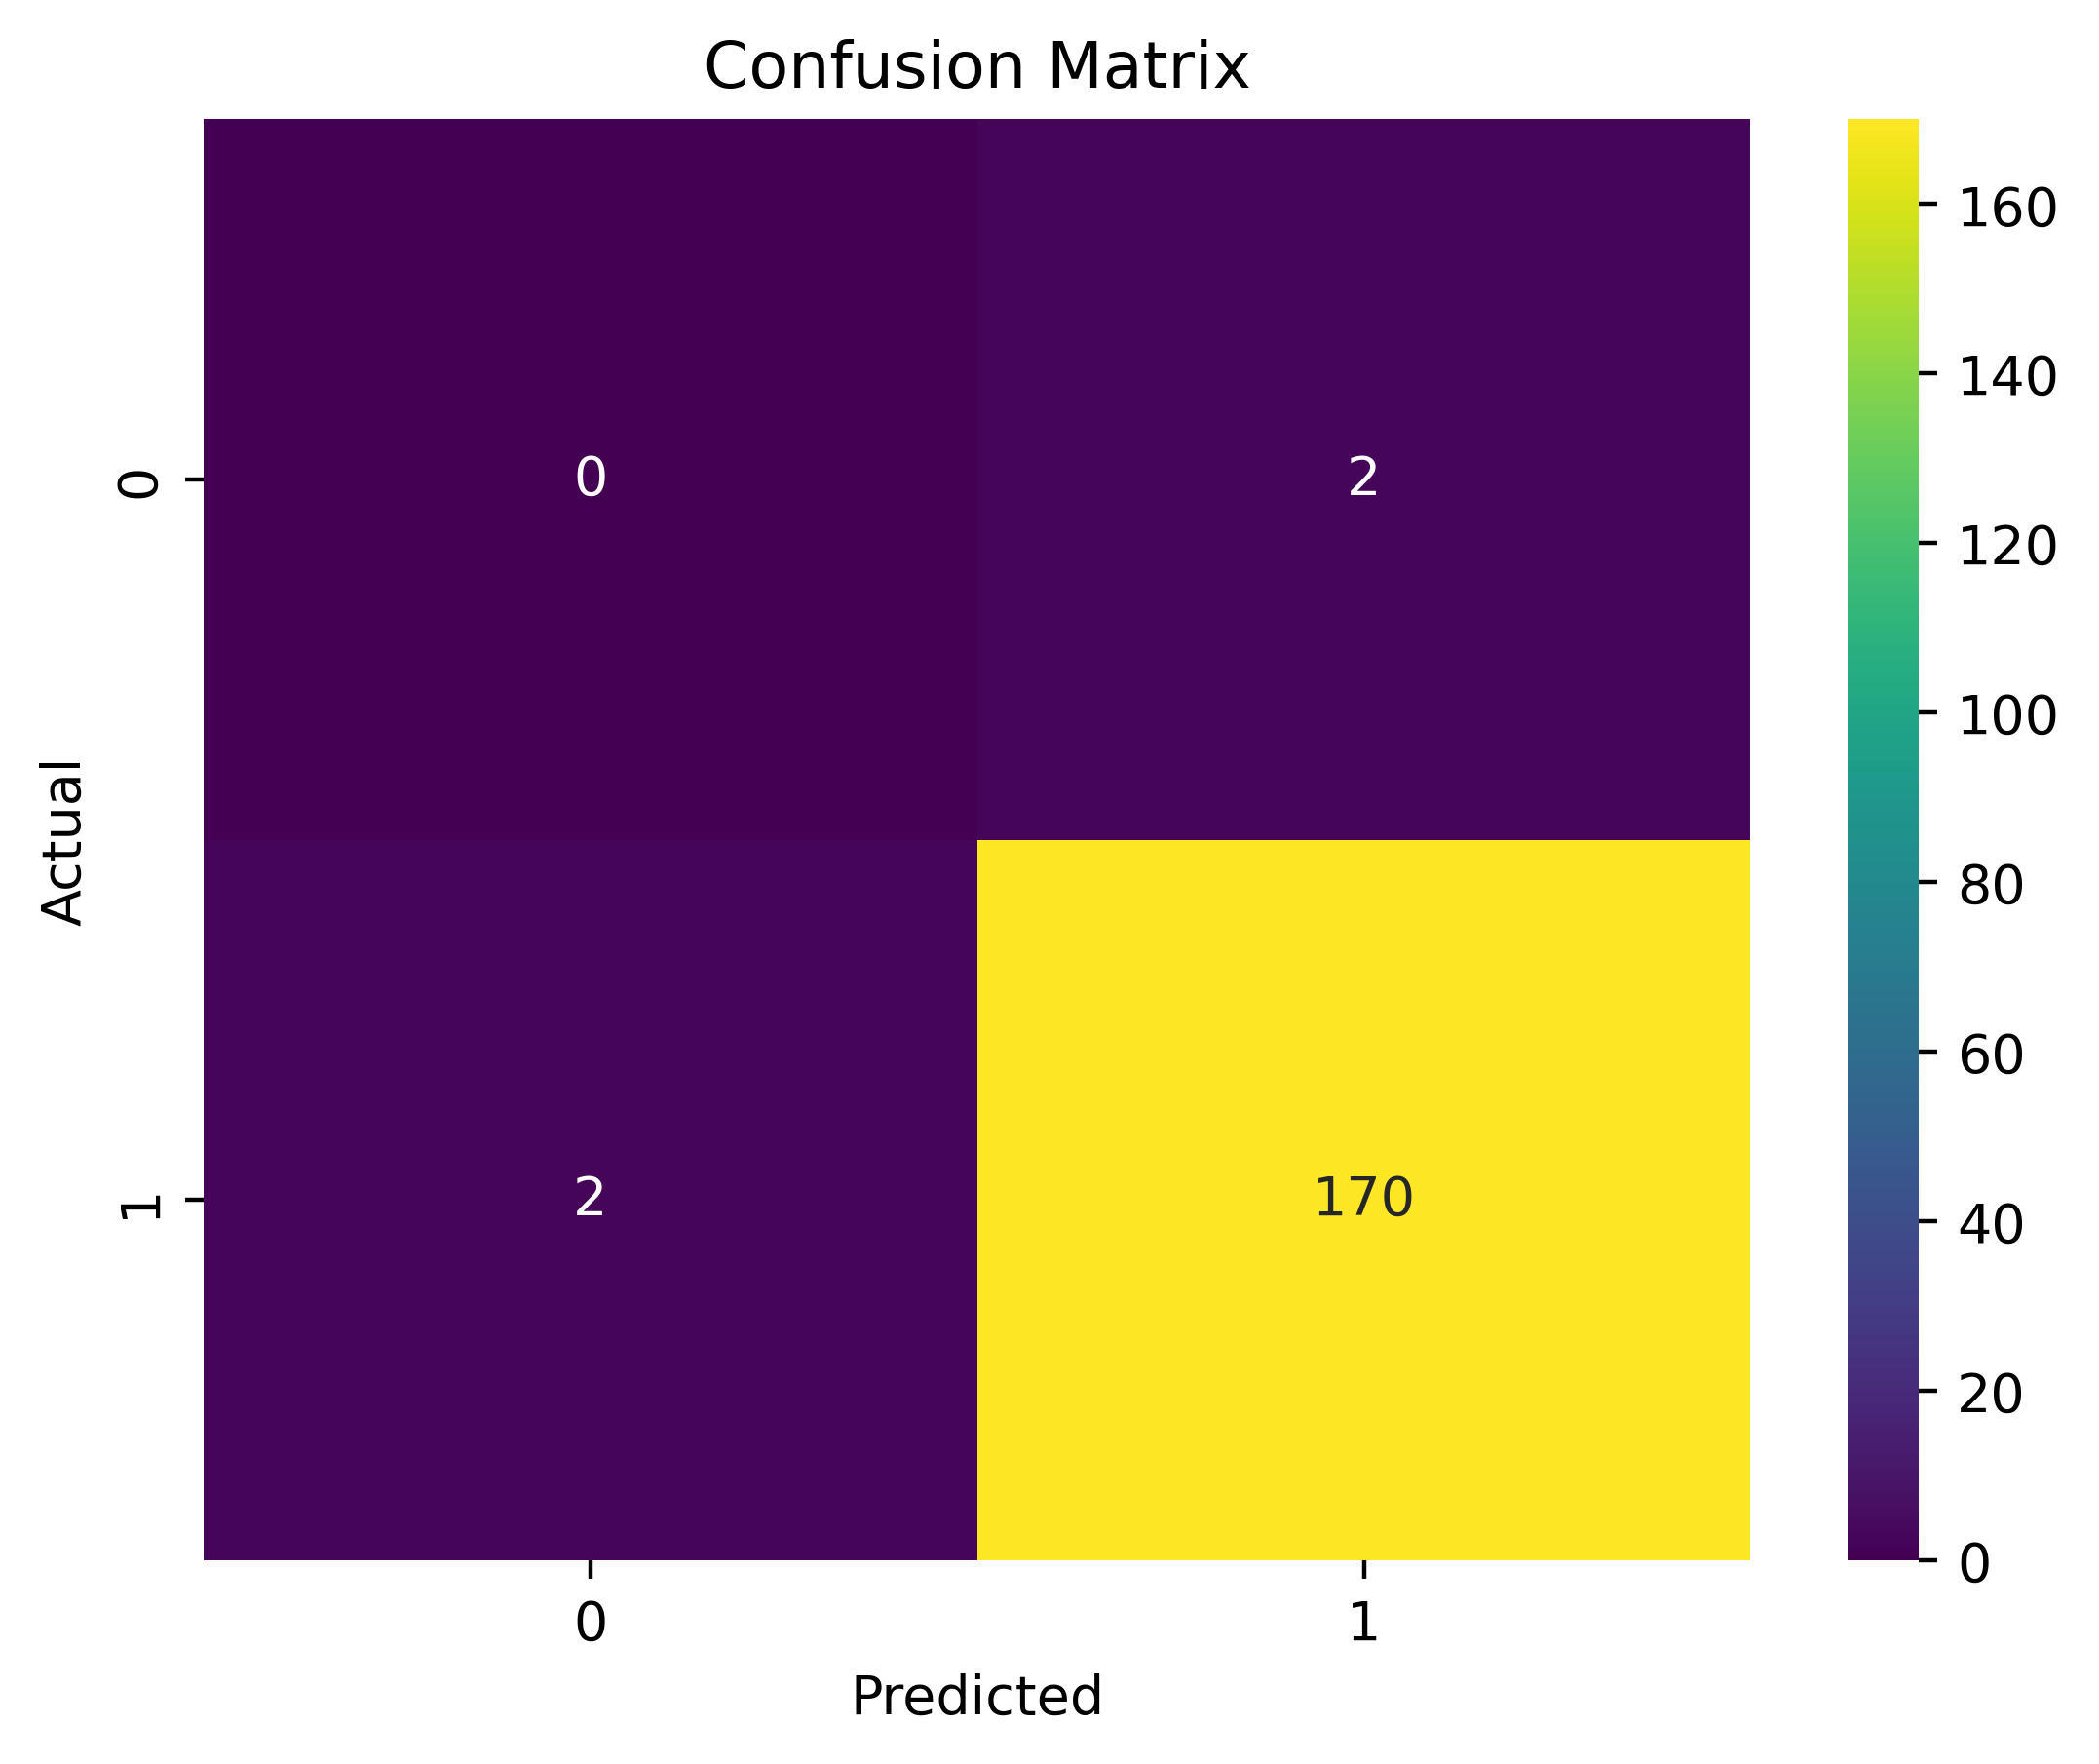

In [32]:
# Vẽ Heatmap ma trận nhầm lẫn
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [44]:
# Báo cáo kết quả
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.99      0.99      0.99       172

    accuracy                           0.98       174
   macro avg       0.49      0.49      0.49       174
weighted avg       0.98      0.98      0.98       174



## 2.3. GIẢI THUẬT 3: BAYES NGÂY THƠ (NAIVE BAYES)

### Bài toán 1

#### Nhiệm vụ 1: Phân loại sử dụng Naive Bayes

In [5]:
# Import thư viện và nạp dữ liệu
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
data = pd.read_csv('Data/spam.csv', encoding='latin-1')
# display the first 5 rows
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
# Tiền xử lý và chia dữ liệu thành 2 tạp huấn luyện và kiểm tra

# Drop the columns with NaN values
data = data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
# Rename columns for clarity:
data.columns = ['label', 'text']
# Separate features (X) and target labels (y)
X = data.drop('label', axis=1)
y = data['label']
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Xây dựng vector hóa nội dung HAM | SPAM của tập train và tập test

from sklearn.feature_extraction.text import CountVectorizer 
vectorizer = CountVectorizer()
# Fit and transform the training data (X_train)
X_train_vectorized = vectorizer.fit_transform(X_train['text'])
# Transform the test data (X_test)
X_test_vectorized = vectorizer.transform(X_test['text'])

In [9]:
# Xây dựng mô hình Naive Bayes
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()
classifier.fit(X_train_vectorized, y_train)

MultinomialNB()

In [10]:
# Đánh giá hiệu quả của mô hình

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Make predictions on the test data
y_pred = classifier.predict(X_test_vectorized)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

Accuracy: 0.98
Confusion Matrix:
[[963   2]
 [ 16 134]]
Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



### Bài tập thực hành 1

In [13]:
# Import thư viện
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [14]:
# Load dữ liệu
df = pd.read_csv("Data/Customer_Behaviour.csv")
print(df.head())
print(df.info())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


In [16]:
# Tiền xử lý dữ liệu
# Mã hóa biến phân loại
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Xác định X và y
X = df.drop(columns=['Purchased'])   # Purchased là biến mục tiêu
y = df['Purchased']

In [17]:
# Chia dữ liệu tỷ lệ 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Xây dựng mô hình Naive Bayes (GaussianNB phù hợp với data này)
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94        52
           1       0.96      0.82      0.88        28

    accuracy                           0.93        80
   macro avg       0.93      0.90      0.91        80
weighted avg       0.93      0.93      0.92        80



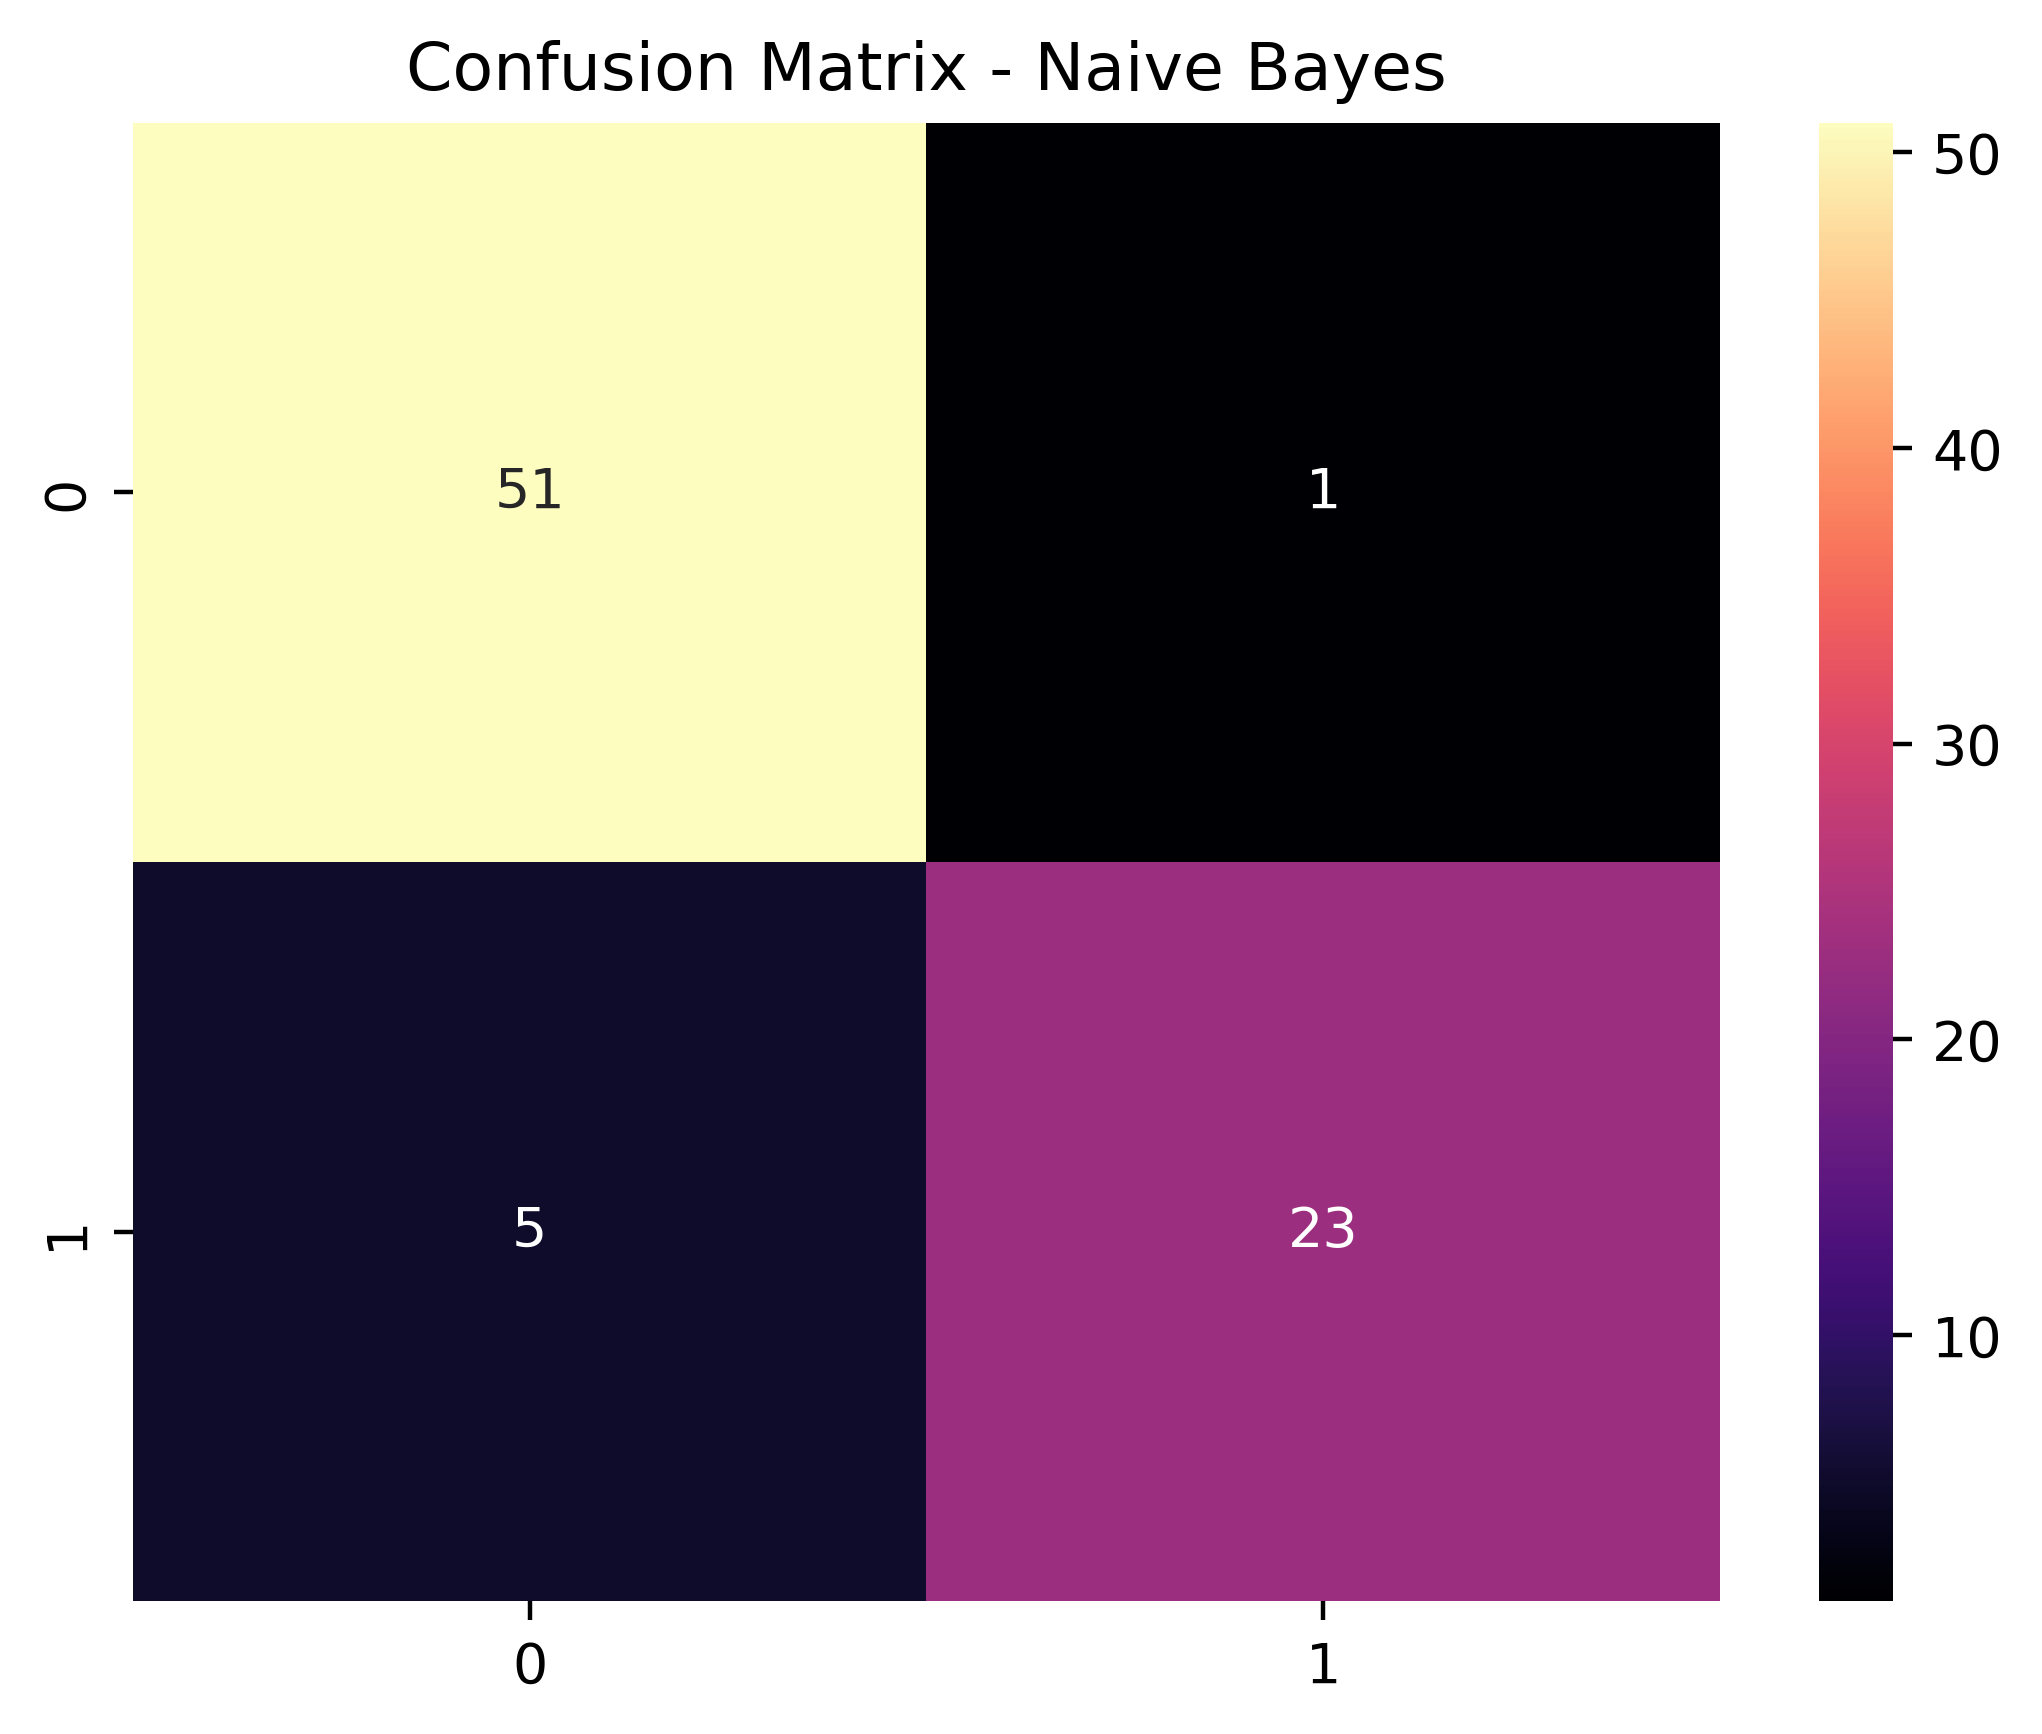

In [21]:
# Dự đoán và đánh giá mô hình

# Dự đoán
y_pred = model.predict(X_test)

# Độ chính xác
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

### Bài tập thực hành 2

In [22]:
# Import thư viện
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [38]:
# Load dữ liệu
df = pd.read_csv("Data/mushrooms.csv")
print(df.head())

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

In [41]:
# Tiền xử lý dữ liệu
# Mã hóa biến phân loại
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
    
# Xác định X và y
X = df.drop(columns=['class'])   # Class là biến mục tiêu, phân loại nấm ăn được (e) và có độc (p)
y = df['class']

['d' 'g' 'l' 'm' 'p' 'u' 'w']


In [42]:
# Chia dữ liệu tỷ lệ 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Xây dựng mô hình Naive Bayes (CategoricalNB là phù hợp nhất vì đây là dữ liệu dạng phân loại)
model = CategoricalNB()
model.fit(X_train, y_train)

CategoricalNB()

In [29]:
# Dự đoán và đánh giá độ chính xác
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9508

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95       843
           1       0.99      0.91      0.95       782

    accuracy                           0.95      1625
   macro avg       0.96      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625



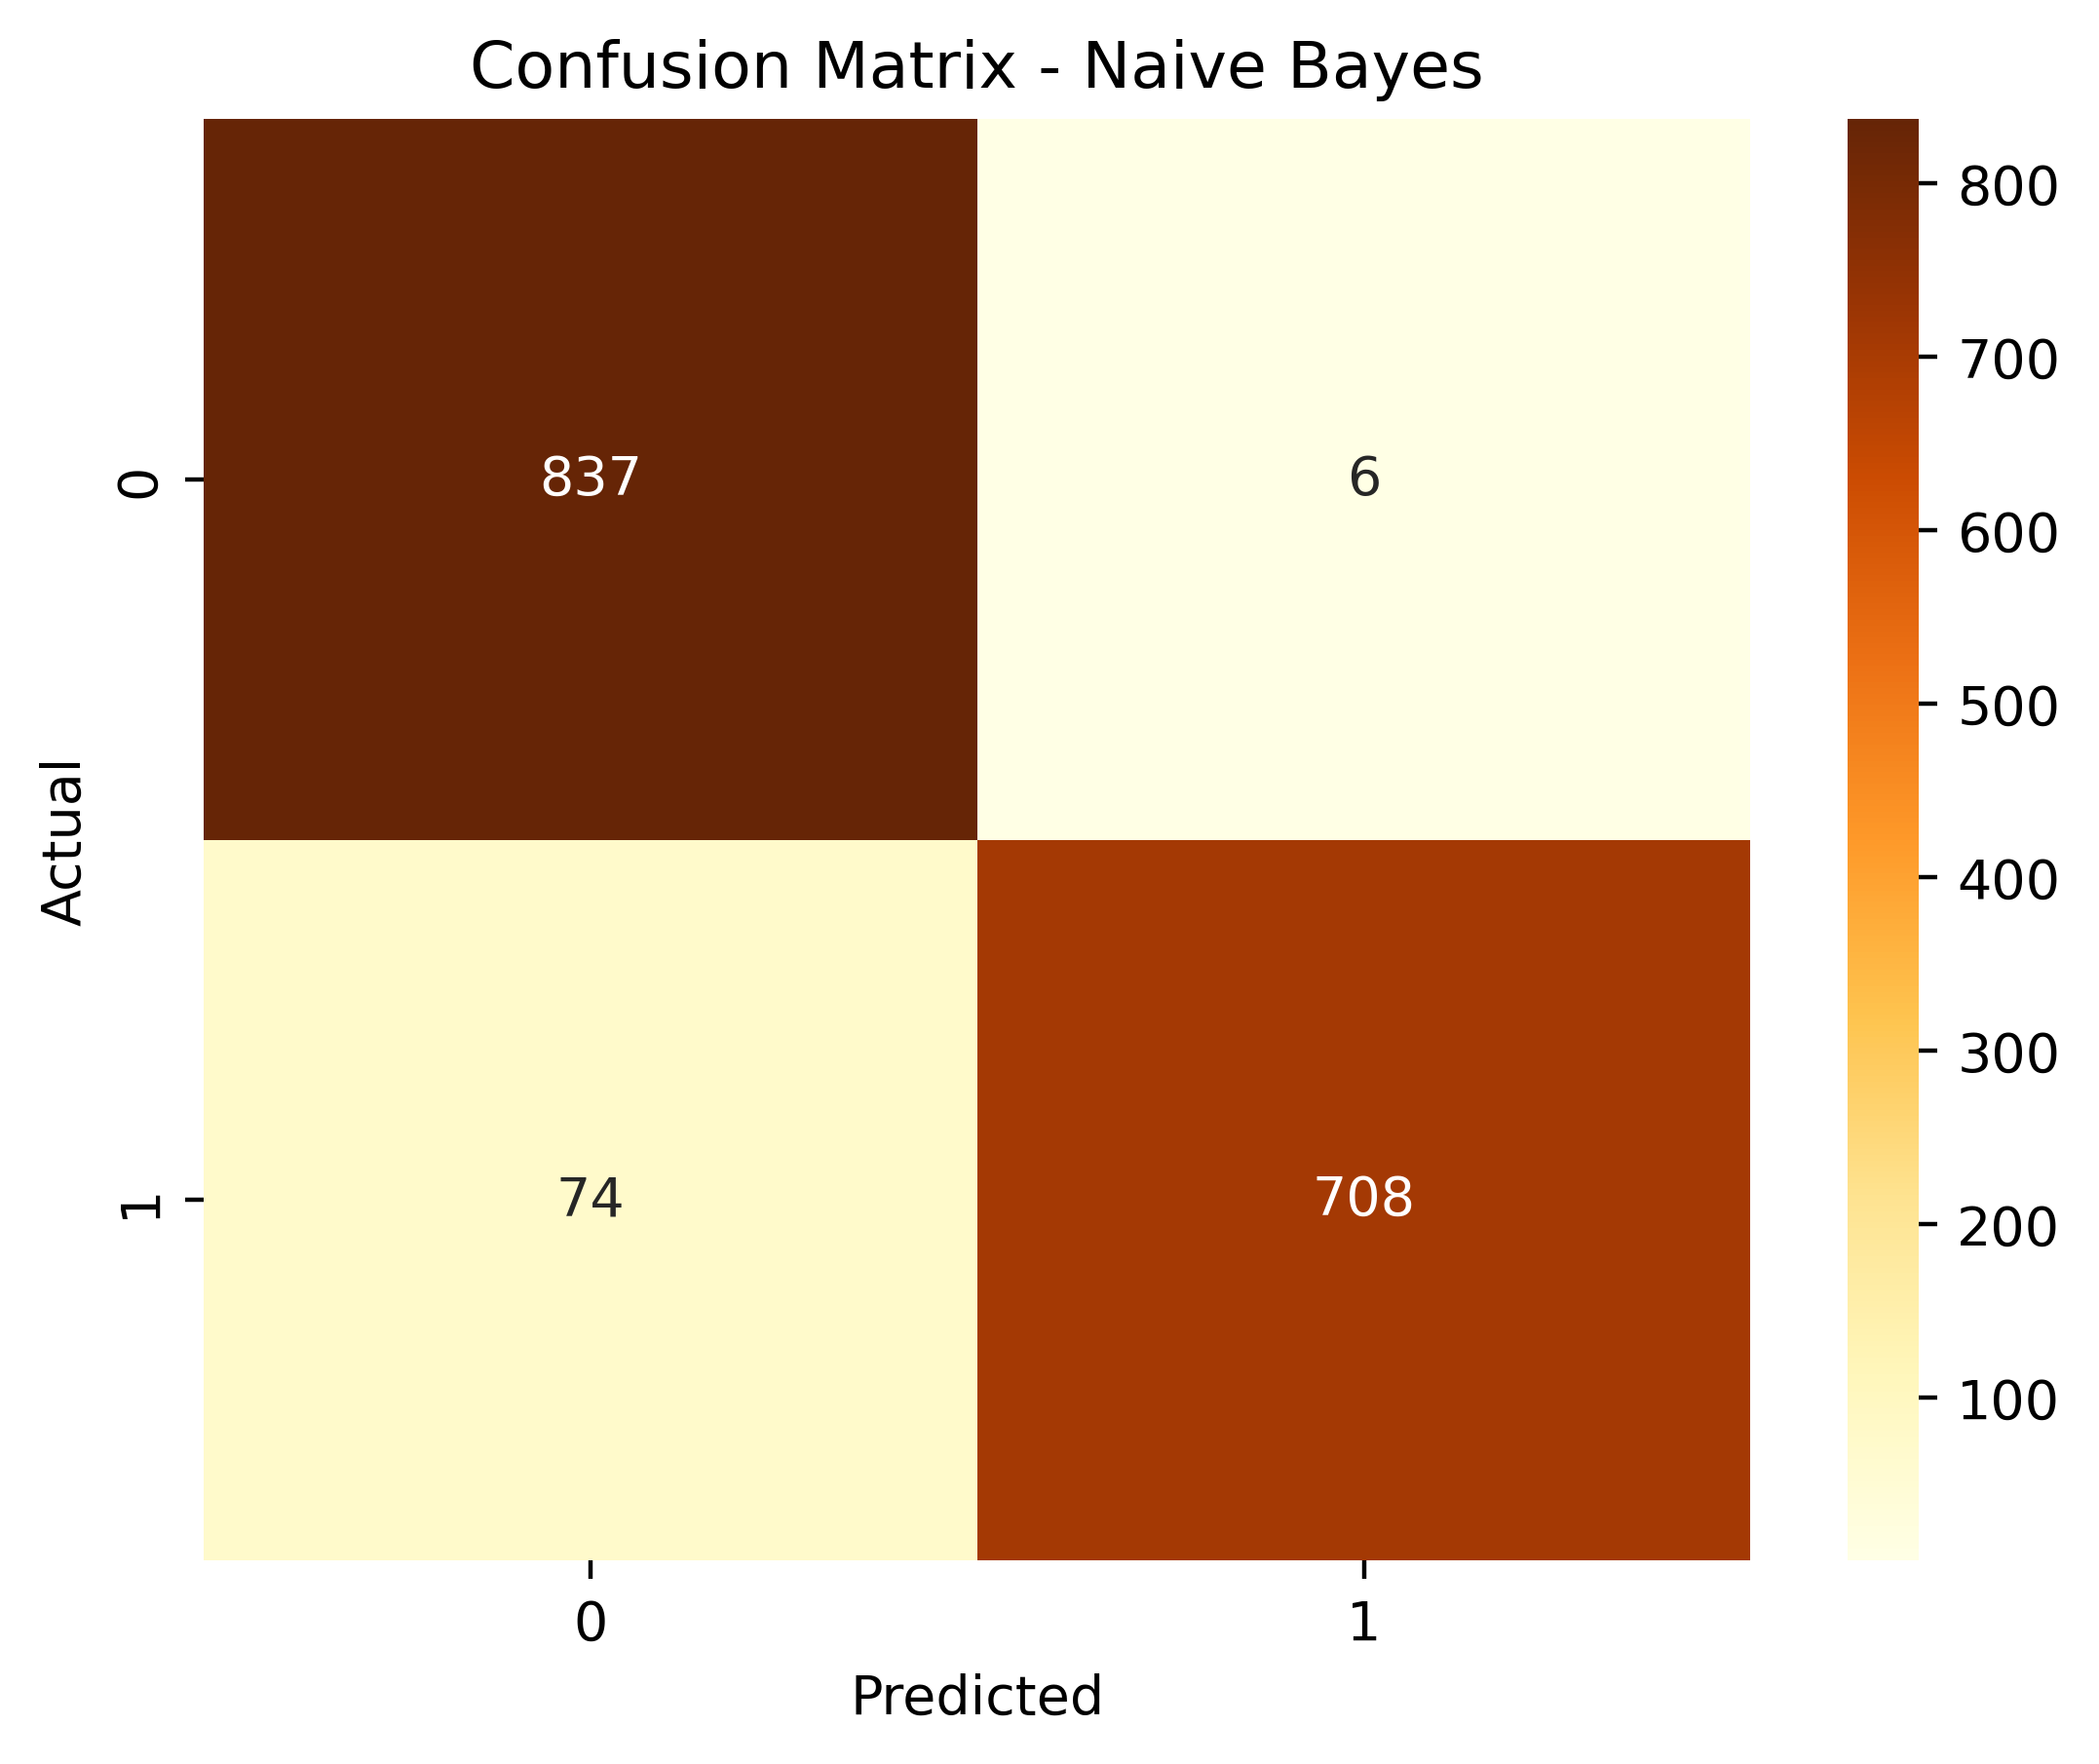

In [36]:
# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# KẾT THÚC LAB 02